# Исправленная методика:модель региональной динамики ИИ-фактора Φr(t) × отраслевой ламповый усилитель

Ноутбук строит сценарную оценку эффекта ИИ для сочетания **«регион × вид экономической деятельности»**.

Исправления относительно предыдущей версии:

1. Региональные и отраслевые профили строятся по **структурным показателям**, а не по абсолютному масштабу расходов.
2. Число кластеров выбирается по коэффициенту силуэта с правилом парсимонии.
3. Будущая траектория $\Phi_r(t)$ задаётся тремя сценариями, а не механическим продолжением скачка последнего года.
4. Используется нормированная ламповая характеристика с законом степени $3/2$ и насыщением.

## Схема стыковки

Региональная модель формирует ИИ-фактор $\Phi_r(t)$ и его безразмерную траекторию:

$$g_r(t)=\frac{\Phi_r(t)}{\Phi_r(2024)}.$$

Отраслевая статистика возвращает денежный масштаб:

$$X_{r,s}(t)=X_{s,2024}\,g_r(t).$$

Нормированная ламповая характеристика отрасли:

$$m_s(z)=\frac{1-\exp(-\lambda_s z^{3/2})}{1-\exp(-\lambda_s)},\qquad z=\frac{X}{X_{s,2024}}.$$

Итоговый сценарный эффект:

$$E_{r,s}(t)=\big[m_s(g_r(t))-1\big]\cdot100\%.$$

Из-за короткого отраслевого ряда физические параметры $K$, $U_a$, $I_s$ и $\mu$ не оцениваются по отдельности: они свёрнуты в один эффективный параметр $\lambda_s$. Это сохраняет закон $3/2$ и насыщение, но не создаёт ложную точность четырёхпараметрической подгонки по четырём точкам.

# Предрассчитанные результаты

## Допущенные отраслевые ламповые характеристики

| Отрасль | R² | Spearman ρ | λ |
|---|---:|---:|---:|
| Научные исследования и разработки | 0.964 | 1.00 | 2.843 |
| Производство компьютеров, электронных и оптических изделий | 0.675 | 0.60 | 23.664 |
| Торговля розничная, кроме торговли автотранспортными средствами и мотоциклами | 0.666 | 0.80 | 20.801 |
| Производство химических веществ и химических продуктов | 0.573 | 0.80 | 2.160 |
| Производство готовых металлических изделий, кроме машин и оборудования | 0.540 | 0.80 | 8.876 |

## Сценарные траектории Φ к 2029 году

| Регион | Сценарий | Темп в год, % | gΦ(2029) |
|---|---|---:|---:|
| Республика Тыва | Базовый | -1.81 | 0.913 |
| Республика Тыва | Консервативный | -5.00 | 0.774 |
| Республика Тыва | Ускоренный | 3.19 | 1.170 |
| Рязанская область | Базовый | 10.21 | 1.626 |
| Рязанская область | Консервативный | 5.21 | 1.289 |
| Рязанская область | Ускоренный | 15.21 | 2.029 |
| Санкт-Петербург | Базовый | 10.27 | 1.630 |
| Санкт-Петербург | Консервативный | 5.27 | 1.293 |
| Санкт-Петербург | Ускоренный | 15.27 | 2.035 |

Слабые модели исключены из количественного блока. Значения за пределами наблюдавшегося отраслевого диапазона отмечены как экстраполяция.


In [1]:
import os
os.environ['OMP_NUM_THREADS']='1'
os.environ['OPENBLAS_NUM_THREADS']='1'
os.environ['MKL_NUM_THREADS']='1'

import re, warnings, zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.optimize import minimize_scalar
from scipy.stats import spearmanr, theilslopes
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',100)
pd.set_option('display.max_colwidth',120)

SEED=0
BASE_YEAR=2024
FORECAST_END=2029
PHI_DEPRECIATION=0.25
R2_MIN=0.50
RHO_MIN=0.50
K_MAX=6
SILHOUETTE_TOL=0.02
TARGET_REGIONS=['Санкт-Петербург','Республика Тыва','Рязанская область']
SCENARIO_SHIFT={'Консервативный':-0.05,'Базовый':0.00,'Ускоренный':0.05}
RESULT_DIR=Path('results_corrected')
RESULT_DIR.mkdir(exist_ok=True)

## 1. Загрузка и проверка данных

In [2]:
def find_file(keywords):
    roots=[Path('/content'),Path.cwd(),Path('/mnt/data')]
    candidates=[]
    for root in roots:
        if not root.exists():
            continue
        for p in root.glob('*.xlsx'):
            name=p.name.lower().replace('ё','е')
            if all(k.lower().replace('ё','е') in name for k in keywords):
                candidates.append(p)
    return sorted(candidates,key=lambda p:p.stat().st_mtime,reverse=True)[0] if candidates else None

def upload_if_colab():
    try:
        from google.colab import files
        files.upload()
    except Exception:
        pass

REGION_FILE=find_file(['combined_2020_2024'])
SECTOR_FILE=find_file(['отраслев']) or find_file(['sector'])
if REGION_FILE is None or SECTOR_FILE is None:
    print('Загрузите региональный и отраслевой Excel-файлы.')
    upload_if_colab()
    REGION_FILE=find_file(['combined_2020_2024'])
    SECTOR_FILE=find_file(['отраслев']) or find_file(['sector'])
if REGION_FILE is None or SECTOR_FILE is None:
    raise FileNotFoundError('Не найдены combined_2020_2024.xlsx и Отраслевой_анализ_РФ.xlsx')
print('Региональный файл:',REGION_FILE)
print('Отраслевой файл:',SECTOR_FILE)

Региональный файл: /content/combined_2020_2024.xlsx
Отраслевой файл: /content/Отраслевой_анализ_РФ.xlsx


In [3]:
regions=pd.read_excel(REGION_FILE,sheet_name='Данные_2020_2024')
sectors=pd.read_excel(SECTOR_FILE,sheet_name=0,dtype={'okved2':str})
regions.columns=regions.columns.astype(str).str.strip()
sectors.columns=sectors.columns.astype(str).str.strip()
sectors=sectors.loc[:,~sectors.columns.duplicated()].copy()

required_r=['region','year','VDS_r','ITcosts_r','RDcosts_r','skvozcosts_r','trainingcosts_r']
required_s=['sector','year','VDS_s','ITcosts_s','skvozcosts_s','trainingcosts_s']
missing_r=[c for c in required_r if c not in regions.columns]
missing_s=[c for c in required_s if c not in sectors.columns]
if missing_r: raise KeyError(f'В региональном файле отсутствуют: {missing_r}')
if missing_s: raise KeyError(f'В отраслевом файле отсутствуют: {missing_s}')

regions['region']=regions['region'].astype(str).str.strip()
sectors['sector']=sectors['sector'].astype(str).str.strip()
for c in required_r[1:]: regions[c]=pd.to_numeric(regions[c],errors='coerce')
for c in required_s[1:]: sectors[c]=pd.to_numeric(sectors[c],errors='coerce')
regions['skvozcosts_r']=regions.groupby('region')['skvozcosts_r'].transform(lambda s:s.fillna(s.median()))
regions[['ITcosts_r','RDcosts_r','skvozcosts_r','trainingcosts_r']]=regions[['ITcosts_r','RDcosts_r','skvozcosts_r','trainingcosts_r']].fillna(0)
regions=regions.dropna(subset=['region','year','VDS_r']).sort_values(['region','year']).reset_index(drop=True)
sectors=sectors.dropna(subset=['sector','year','VDS_s','ITcosts_s']).sort_values(['sector','year']).reset_index(drop=True)

print(f"Регионов: {regions.region.nunique()}, наблюдений: {len(regions)}, период: {int(regions.year.min())}–{int(regions.year.max())}")
print(f"Видов деятельности: {sectors.sector.nunique()}, наблюдений: {len(sectors)}, период: {int(sectors.year.min())}–{int(sectors.year.max())}")

Регионов: 79, наблюдений: 395, период: 2020–2024
Видов деятельности: 40, наблюдений: 141, период: 2021–2024


### Денежный масштаб отраслевых показателей

В отраслевом файле `skvozcosts_s` и `trainingcosts_s` являются долями от `ITcosts_s`. Поэтому абсолютные расходы рассчитываются как произведение доли и общих IT-затрат.

In [4]:
def share_to_fraction(s):
    s=pd.to_numeric(s,errors='coerce')
    med=s.dropna().median()
    return s/100 if pd.notna(med) and med>1 else s

sectors['skvoz_share_s']=share_to_fraction(sectors['skvozcosts_s']).clip(lower=0)
sectors['training_share_s']=share_to_fraction(sectors['trainingcosts_s']).clip(lower=0)
sectors['skvozcosts_abs_s']=sectors['ITcosts_s']*sectors['skvoz_share_s']
sectors['trainingcosts_abs_s']=sectors['ITcosts_s']*sectors['training_share_s']
if 'RDcosts_s' not in sectors.columns:
    print('RDcosts_s отсутствует: отраслевой профиль строится по IT-интенсивности, доле сквозных технологий и доле обучения.')
display(sectors[['sector','year','VDS_s','ITcosts_s','skvoz_share_s','training_share_s','skvozcosts_abs_s']].head())

RDcosts_s отсутствует: отраслевой профиль строится по IT-интенсивности, доле сквозных технологий и доле обучения.


,sector,year,VDS_s,ITcosts_s,skvoz_share_s,training_share_s,skvozcosts_abs_s
0,Аренда и лизинг,2021,9.502345e+05,3253.057084,0.000327,0.001167,1.062676
1,Аренда и лизинг,2022,9.719472e+05,21731.663739,0.000030,0.005021,0.658080
2,Аренда и лизинг,2024,8.404207e+05,22097.462449,0.000010,0.008926,0.231547
3,"Деятельность в области архитектуры и инженерно-технического проектирования; технических испытаний, исследований и ан...",2021,1.230284e+06,94580.340012,0.004118,0.002943,389.500069
4,"Деятельность в области архитектуры и инженерно-технического проектирования; технических испытаний, исследований и ан...",2022,1.713110e+06,77023.192479,0.009486,0.003057,730.677132


## 2. Функции структурной кластеризации

In [5]:
def choose_best_year(df,entity,target,columns):
    idx=df.groupby(entity)[target].idxmax()
    return df.loc[idx,[entity,'year',target]+columns].reset_index(drop=True)

def log_standardize(df,features):
    transformed=[]
    eps={}
    for f in features:
        x=pd.to_numeric(df[f],errors='coerce').fillna(0).clip(lower=0).to_numpy(float)
        positive=x[x>0]
        e=float(positive.min()/2) if len(positive) else 1e-12
        eps[f]=e
        transformed.append(np.log10(x+e))
    scaler=StandardScaler()
    Z=scaler.fit_transform(np.column_stack(transformed))
    return Z,scaler,eps

def silhouette_diagnostics(Z,k_max=6):
    rows=[]
    n=len(Z)
    min_allowed=max(3,int(np.ceil(n*0.05)))
    for k in range(2,min(k_max,n-1)+1):
        labels=KMeans(n_clusters=k,n_init=30,random_state=SEED).fit_predict(Z)
        counts=np.bincount(labels)
        rows.append([k,silhouette_score(Z,labels),int(counts.min()),bool(counts.min()>=min_allowed)])
    result=pd.DataFrame(rows,columns=['k','silhouette','min_cluster_size','size_ok'])
    valid=result[result.size_ok]
    if valid.empty: valid=result
    best=float(valid.silhouette.max())
    eligible=valid[valid.silhouette>=best-SILHOUETTE_TOL]
    chosen=int(eligible.k.min())
    return result,chosen

def cluster_structures(df,entity,features):
    Z,scaler,eps=log_standardize(df,features)
    diag,k=silhouette_diagnostics(Z,K_MAX)
    model=KMeans(n_clusters=k,n_init=100,random_state=SEED).fit(Z)
    result=df.copy()
    result['cluster_raw']=model.labels_
    order=(result.groupby('cluster_raw')[features[0]].median().sort_values().index.tolist())
    remap={old:new for new,old in enumerate(order)}
    result['cluster']=result.cluster_raw.map(remap)
    for f in features:
        result[f+'_percentile']=result[f].rank(pct=True)*100
    return result,diag,k,model,scaler,eps

def plot_silhouette(diag,chosen,title,filename):
    fig,ax=plt.subplots(figsize=(7.5,4.5))
    ax.plot(diag.k,diag.silhouette,marker='o')
    y=float(diag.loc[diag.k.eq(chosen),'silhouette'].iloc[0])
    ax.scatter([chosen],[y],s=100,label=f'выбрано k={chosen}')
    for _,r in diag.iterrows():
        ax.annotate(f"min n={int(r.min_cluster_size)}",(r.k,r.silhouette),xytext=(0,8),textcoords='offset points',ha='center',fontsize=8)
    ax.set_xlabel('Число кластеров k')
    ax.set_ylabel('Коэффициент силуэта')
    ax.set_title(title)
    ax.grid(alpha=.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(RESULT_DIR/filename,dpi=180,bbox_inches='tight')
    plt.show(); plt.close(fig)

## 3. Профильный анализ регионов

Структурные признаки не зависят напрямую от размера территории:

- цифровая интенсивность: $(IT+RD)/VDS$;
- баланс НИОКР и IT: $RD/(IT+RD)$;
- интенсивность сквозных технологий: $Skvoz/IT$;
- интенсивность обучения: $Training/IT$.

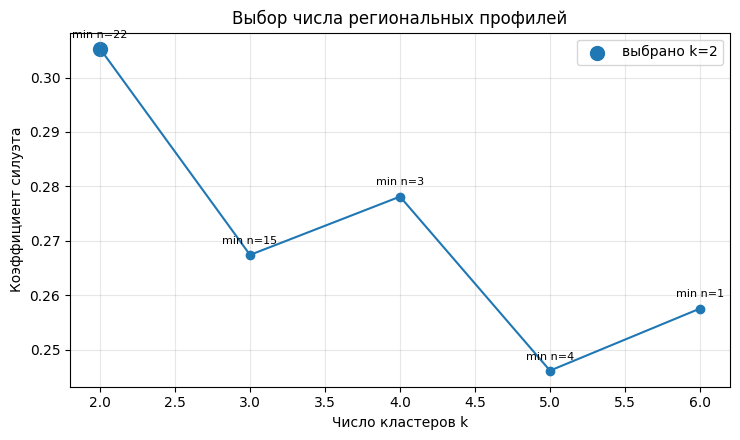

Выбрано региональных профилей: 2


,k,silhouette,min_cluster_size,size_ok
0,2,0.305315,22,True
1,3,0.267409,15,True
2,4,0.278125,3,False
3,5,0.246140,4,True
4,6,0.257548,1,False


In [6]:
REGION_RAW=['ITcosts_r','RDcosts_r','skvozcosts_r','trainingcosts_r']
PROFILE_YEARS=[2021,2022,2023,2024]
# Профили регионов строятся по СРЕДНИМ за 2021-2024 (устойчивее одного года с макс. ВДС)
region_best=(regions[regions.year.isin(PROFILE_YEARS)]
             .groupby('region')[['VDS_r']+REGION_RAW].mean().reset_index())
region_best.insert(1,'year','2021–2024')
region_best['digital_intensity']=(region_best.ITcosts_r+region_best.RDcosts_r)/region_best.VDS_r.replace(0,np.nan)
region_best['RD_share']=region_best.RDcosts_r/(region_best.ITcosts_r+region_best.RDcosts_r).replace(0,np.nan)
region_best['Skvoz_per_IT']=region_best.skvozcosts_r/region_best.ITcosts_r.replace(0,np.nan)
region_best['Training_per_IT']=region_best.trainingcosts_r/region_best.ITcosts_r.replace(0,np.nan)
REGION_FEATURES=['digital_intensity','RD_share','Skvoz_per_IT','Training_per_IT']
REGION_LABELS={'digital_intensity':'(IT+НИОКР)/ВДС','RD_share':'доля НИОКР в IT+НИОКР','Skvoz_per_IT':'сквозные/IT','Training_per_IT':'обучение/IT'}
region_profiles,region_diag,K_REGIONS,region_model,_,_=cluster_structures(region_best,'region',REGION_FEATURES)
plot_silhouette(region_diag,K_REGIONS,'Выбор числа региональных профилей','01_силуэт_регионы.png')
print('Выбрано региональных профилей:',K_REGIONS)
display(region_diag)

> **О числе профилей.** Коэффициент силуэта здесь невысокий (порядка 0.2–0.3), и формальный максимум часто приходится на k=2. Это значит, что структурные показатели регионов образуют **континуум**, а не резко обособленные группы. Поэтому профили трактуются как удобное деление непрерывного распределения (с опорой на интерпретируемость), а не как объективно существующие кластеры. Содержательные выводы делаются по положению региона на осях (доля НИОКР, цифровая интенсивность), а не по номеру кластера.

In [7]:
def name_region_profiles(df):
    overall=df[REGION_FEATURES].median()
    names={}
    for c,g in df.groupby('cluster'):
        med=g[REGION_FEATURES].median()
        base='НИОКР-ориентированный' if med.RD_share>overall.RD_share*1.15 else 'IT-ориентированный'
        tags=[]
        if med.digital_intensity>overall.digital_intensity*1.15: tags.append('высокая цифровая интенсивность')
        if med.Skvoz_per_IT>overall.Skvoz_per_IT*1.25: tags.append('повышенная доля сквозных технологий')
        if med.Training_per_IT>overall.Training_per_IT*1.25: tags.append('повышенная доля обучения')
        names[c]=base+('; '+', '.join(tags) if tags else '')
    return names

REGION_PROFILE_NAMES=name_region_profiles(region_profiles)
region_profiles['profile']=region_profiles.cluster.map(REGION_PROFILE_NAMES)
region_centers=region_profiles.groupby(['cluster','profile'])[REGION_FEATURES].median().reset_index()
display(region_centers)

,cluster,profile,digital_intensity,RD_share,Skvoz_per_IT,Training_per_IT
0,0,IT-ориентированный,0.012404,0.225500,0.002430,0.001049
1,1,"НИОКР-ориентированный; высокая цифровая интенсивность, повышенная доля сквозных технологий, повышенная доля обучения",0.028706,0.462424,0.005866,0.002336


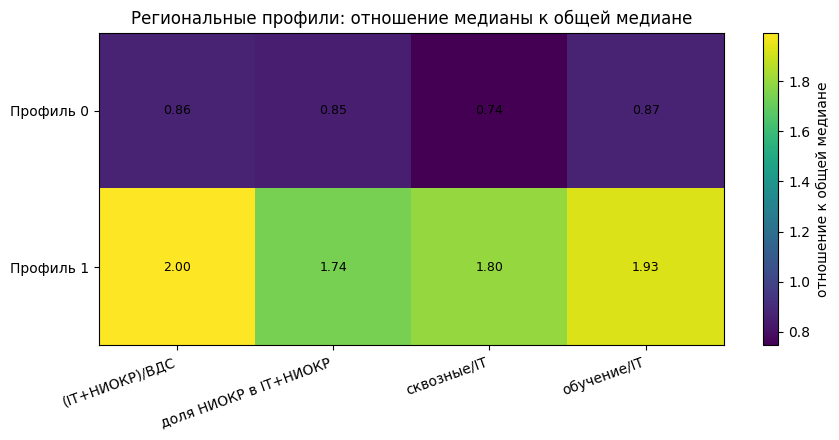

In [8]:
# Тепловая карта медианных структур региональных профилей относительно общей медианы
ratio=region_centers[REGION_FEATURES].div(region_profiles[REGION_FEATURES].median(),axis=1)
fig,ax=plt.subplots(figsize=(9,4.5))
im=ax.imshow(ratio.values,aspect='auto')
ax.set_xticks(range(len(REGION_FEATURES)),[REGION_LABELS[f] for f in REGION_FEATURES],rotation=20,ha='right')
ax.set_yticks(range(len(ratio)),[f'Профиль {int(c)}' for c in region_centers.cluster])
for i in range(len(ratio)):
    for j in range(len(REGION_FEATURES)):
        ax.text(j,i,f'{ratio.iloc[i,j]:.2f}',ha='center',va='center',fontsize=9)
ax.set_title('Региональные профили: отношение медианы к общей медиане')
fig.colorbar(im,ax=ax,label='отношение к общей медиане')
fig.tight_layout()
fig.savefig(RESULT_DIR/'02_центры_региональных_профилей.png',dpi=180,bbox_inches='tight')
plt.show(); plt.close(fig)

In [9]:
def resolve_region(name,available):
    matches=[x for x in available if name.lower() in x.lower()]
    if not matches: raise KeyError(f'Регион не найден: {name}')
    return matches[0]

REGION_MATCH={name:resolve_region(name,regions.region.unique()) for name in TARGET_REGIONS}
selected_region_profiles=region_profiles[region_profiles.region.isin(REGION_MATCH.values())].copy()
selected_region_profiles['region_short']=selected_region_profiles.region.map({v:k for k,v in REGION_MATCH.items()})
display(selected_region_profiles[['region_short','year','VDS_r','cluster','profile']+REGION_FEATURES].sort_values('region_short'))

,region_short,year,VDS_r,cluster,profile,digital_intensity,RD_share,Skvoz_per_IT,Training_per_IT
55,Республика Тыва,2021–2024,1.202331e+05,0,IT-ориентированный,0.014054,0.247696,0.000473,0.000874
58,Рязанская область,2021–2024,6.783851e+05,0,IT-ориентированный,0.018112,0.188887,0.001040,0.001410
11,Санкт-Петербург,2021–2024,1.122768e+07,1,"НИОКР-ориентированный; высокая цифровая интенсивность, повышенная доля сквозных технологий, повышенная доля обучения",0.044601,0.447453,0.019526,0.001534


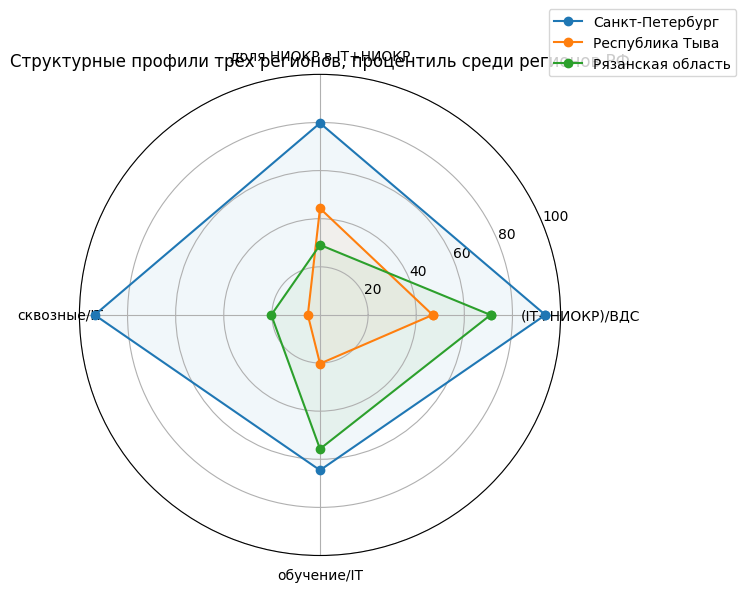

In [10]:
# Радар выбранных регионов: процентиль структурных показателей среди регионов РФ
angles=np.linspace(0,2*np.pi,len(REGION_FEATURES),endpoint=False)
angles=np.r_[angles,angles[0]]
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,polar=True)
for _,row in selected_region_profiles.iterrows():
    vals=np.array([row[f+'_percentile'] for f in REGION_FEATURES])
    ax.plot(angles,np.r_[vals,vals[0]],marker='o',label=row.region_short)
    ax.fill(angles,np.r_[vals,vals[0]],alpha=.06)
ax.set_xticks(angles[:-1])
ax.set_xticklabels([REGION_LABELS[f] for f in REGION_FEATURES])
ax.set_ylim(0,100)
ax.set_title('Структурные профили трёх регионов, процентиль среди регионов РФ')
ax.legend(loc='upper right',bbox_to_anchor=(1.38,1.15))
fig.tight_layout()
fig.savefig(RESULT_DIR/'03_профили_трех_регионов.png',dpi=180,bbox_inches='tight')
plt.show(); plt.close(fig)

## 4. Профильный анализ видов экономической деятельности

Поскольку `skvozcosts_s` и `trainingcosts_s` являются компонентами IT-затрат, они не складываются с `ITcosts_s`. Используются:

- $IT/VDS$ — общая цифровая интенсивность;
- доля сквозных технологий в IT;
- доля обучения в IT;
- при наличии `RDcosts_s` — $RD/VDS$.

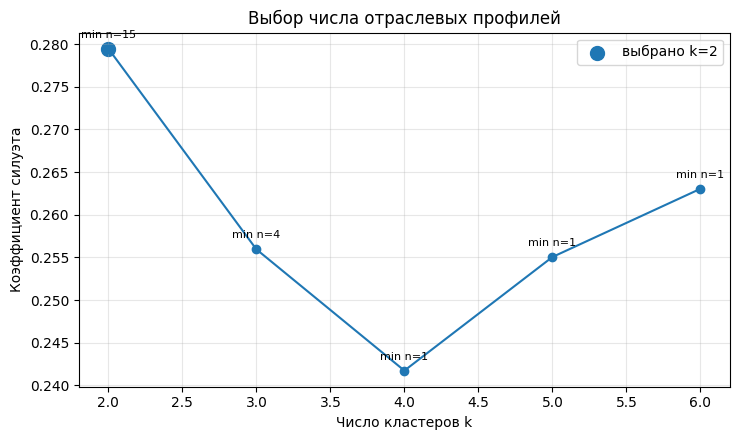

Выбрано отраслевых профилей: 2


,k,silhouette,min_cluster_size,size_ok
0,2,0.279465,15,True
1,3,0.255944,4,True
2,4,0.241726,1,False
3,5,0.255043,1,False
4,6,0.263039,1,False


In [11]:
sector_best=choose_best_year(sectors,'sector','VDS_s',['ITcosts_s','skvoz_share_s','training_share_s']+(['RDcosts_s'] if 'RDcosts_s' in sectors.columns else []))
sector_best['IT_intensity']=sector_best.ITcosts_s/sector_best.VDS_s.replace(0,np.nan)
sector_best['Skvoz_share']=sector_best.skvoz_share_s
sector_best['Training_share']=sector_best.training_share_s
SECTOR_FEATURES=['IT_intensity','Skvoz_share','Training_share']
SECTOR_LABELS={'IT_intensity':'IT/ВДС','Skvoz_share':'доля сквозных в IT','Training_share':'доля обучения в IT'}
if 'RDcosts_s' in sector_best.columns:
    sector_best['RD_intensity']=pd.to_numeric(sector_best.RDcosts_s,errors='coerce')/sector_best.VDS_s.replace(0,np.nan)
    SECTOR_FEATURES.append('RD_intensity')
    SECTOR_LABELS['RD_intensity']='НИОКР/ВДС'
sector_profiles,sector_diag,K_SECTORS,sector_model,_,_=cluster_structures(sector_best,'sector',SECTOR_FEATURES)
plot_silhouette(sector_diag,K_SECTORS,'Выбор числа отраслевых профилей','04_силуэт_отрасли.png')
print('Выбрано отраслевых профилей:',K_SECTORS)
display(sector_diag)

In [12]:
def name_sector_profiles(df):
    overall=df[SECTOR_FEATURES].median()
    names={}
    for c,g in df.groupby('cluster'):
        med=g[SECTOR_FEATURES].median()
        tags=['высокая IT-интенсивность' if med.IT_intensity>overall.IT_intensity else 'умеренная IT-интенсивность']
        if med.Skvoz_share>overall.Skvoz_share*1.20: tags.append('акцент на сквозные технологии')
        if med.Training_share>overall.Training_share*1.20: tags.append('акцент на обучение')
        if 'RD_intensity' in med.index and med.RD_intensity>overall.RD_intensity*1.20: tags.append('акцент на НИОКР')
        names[c]='; '.join(tags)
    return names

SECTOR_PROFILE_NAMES=name_sector_profiles(sector_profiles)
sector_profiles['profile']=sector_profiles.cluster.map(SECTOR_PROFILE_NAMES)
sector_centers=sector_profiles.groupby(['cluster','profile'])[SECTOR_FEATURES].median().reset_index()
sector_summary=sector_profiles.groupby(['cluster','profile']).agg(n=('sector','size'),median_VDS=('VDS_s','median')).reset_index()
display(sector_summary)

,cluster,profile,n,median_VDS
0,0,умеренная IT-интенсивность; акцент на сквозные технологии,25,1.743255e+06
1,1,высокая IT-интенсивность; акцент на обучение,15,6.153249e+05


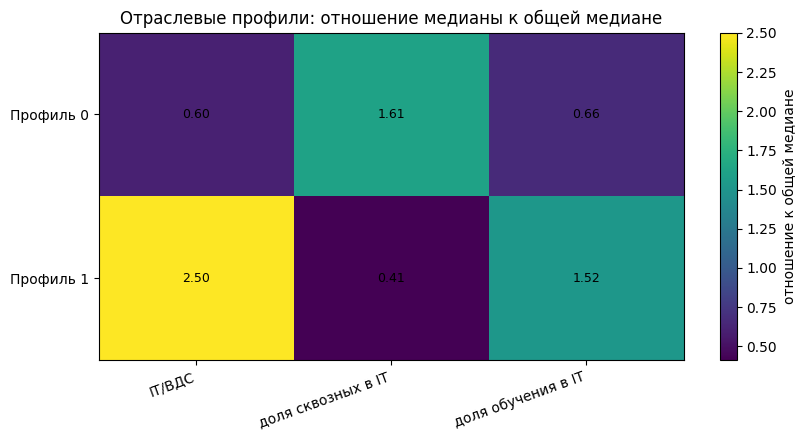

In [13]:
ratio=sector_centers[SECTOR_FEATURES].div(sector_profiles[SECTOR_FEATURES].median(),axis=1)
fig,ax=plt.subplots(figsize=(8.5,4.5))
im=ax.imshow(ratio.values,aspect='auto')
ax.set_xticks(range(len(SECTOR_FEATURES)),[SECTOR_LABELS[f] for f in SECTOR_FEATURES],rotation=20,ha='right')
ax.set_yticks(range(len(ratio)),[f'Профиль {int(c)}' for c in sector_centers.cluster])
for i in range(len(ratio)):
    for j in range(len(SECTOR_FEATURES)):
        ax.text(j,i,f'{ratio.iloc[i,j]:.2f}',ha='center',va='center',fontsize=9)
ax.set_title('Отраслевые профили: отношение медианы к общей медиане')
fig.colorbar(im,ax=ax,label='отношение к общей медиане')
fig.tight_layout()
fig.savefig(RESULT_DIR/'05_центры_отраслевых_профилей.png',dpi=180,bbox_inches='tight')
plt.show(); plt.close(fig)

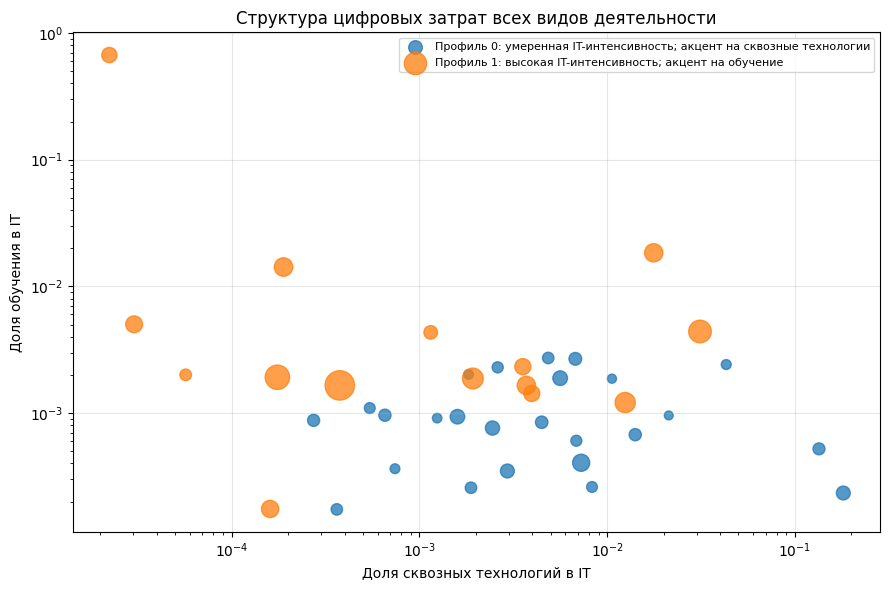

In [14]:
# Все отрасли на плоскости долей сквозных технологий и обучения
fig,ax=plt.subplots(figsize=(9,6))
for c,g in sector_profiles.groupby('cluster'):
    ax.scatter(g.Skvoz_share,g.Training_share,s=35+5000*g.IT_intensity,label=f'Профиль {c}: {SECTOR_PROFILE_NAMES[c]}',alpha=.75)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Доля сквозных технологий в IT')
ax.set_ylabel('Доля обучения в IT')
ax.set_title('Структура цифровых затрат всех видов деятельности')
ax.grid(alpha=.3)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(RESULT_DIR/'06_карта_отраслевых_профилей.png',dpi=180,bbox_inches='tight')
plt.show(); plt.close(fig)

## 5. Исторический $\Phi_r(t)$ и сценарный прогноз

Исторический запас строится методом непрерывной инвентаризации:

$$\Phi_{r,t}=(1-\delta_\Phi)\Phi_{r,t-1}+skvozcosts_{r,t},\qquad \delta_\Phi=0.25.$$

Центральный темп будущего роста определяется по робастному тренду всего ряда $\Phi_r(t)$ и мягко сжимается к нулю. Затем строятся три сценария: центральный темп минус 5 п.п., центральный темп и центральный темп плюс 5 п.п. Поэтому результат не зависит от одного скачка последнего года.

In [15]:
def historical_phi(g,delta=PHI_DEPRECIATION):
    g=g.sort_values('year')[['year','skvozcosts_r']].copy()
    state=None; values=[]
    for flow in g.skvozcosts_r.clip(lower=0):
        state=float(flow) if state is None else (1-delta)*state+float(flow)
        values.append(state)
    g['Phi']=values
    return g

def soft_shrink_rate(raw,scale=0.12):
    return float(scale*raw/(scale+abs(raw))) if np.isfinite(raw) else 0.0

def build_phi_scenarios(df,region_full,region_short):
    hist=historical_phi(df[df.region.eq(region_full)])
    hist=hist[hist.year<=BASE_YEAR].copy()
    if BASE_YEAR not in hist.year.values: raise ValueError(f'Нет {BASE_YEAR} года для {region_short}')
    slope=theilslopes(np.log(hist.Phi.clip(lower=1e-12)),hist.year).slope
    raw_rate=float(np.expm1(slope))
    base_rate=soft_shrink_rate(raw_rate)
    phi0=float(hist.loc[hist.year.eq(BASE_YEAR),'Phi'].iloc[-1])
    rows=[]
    for scenario,shift in SCENARIO_SHIFT.items():
        rate=float(np.clip(base_rate+shift,-0.05,0.17))
        for year in range(int(hist.year.min()),FORECAST_END+1):
            if year<=BASE_YEAR:
                phi=float(hist.loc[hist.year.eq(year),'Phi'].iloc[-1])
                phase='факт'
                g_phi=phi/phi0
                implied_flow=float(hist.loc[hist.year.eq(year),'skvozcosts_r'].iloc[-1])
            else:
                phi=phi0*(1+rate)**(year-BASE_YEAR)
                prev=phi0*(1+rate)**(year-BASE_YEAR-1)
                implied_flow=phi-(1-PHI_DEPRECIATION)*prev
                phase='сценарий'
                g_phi=phi/phi0
            rows.append([region_short,scenario,year,phase,phi,g_phi,implied_flow,raw_rate,base_rate,rate])
    return pd.DataFrame(rows,columns=['region','scenario','year','phase','Phi','g_phi','implied_skvoz_flow','raw_trend_rate','shrunk_base_rate','scenario_rate'])

phi_parts=[]
for short_name,full_name in REGION_MATCH.items():
    phi_parts.append(build_phi_scenarios(regions,full_name,short_name))
phi=pd.concat(phi_parts,ignore_index=True)
rate_table=phi[phi.year.eq(FORECAST_END)][['region','scenario','raw_trend_rate','shrunk_base_rate','scenario_rate']].drop_duplicates()
for c in ['raw_trend_rate','shrunk_base_rate','scenario_rate']:
    rate_table[c]=(rate_table[c]*100).round(2)
display(rate_table.sort_values(['region','scenario']))

,region,scenario,raw_trend_rate,shrunk_base_rate,scenario_rate
49,Республика Тыва,Базовый,-2.13,-1.81,-1.81
39,Республика Тыва,Консервативный,-2.13,-1.81,-5.00
59,Республика Тыва,Ускоренный,-2.13,-1.81,3.19
79,Рязанская область,Базовый,68.26,10.21,10.21
69,Рязанская область,Консервативный,68.26,10.21,5.21
89,Рязанская область,Ускоренный,68.26,10.21,15.21
19,Санкт-Петербург,Базовый,71.05,10.27,10.27
9,Санкт-Петербург,Консервативный,71.05,10.27,5.27
29,Санкт-Петербург,Ускоренный,71.05,10.27,15.27


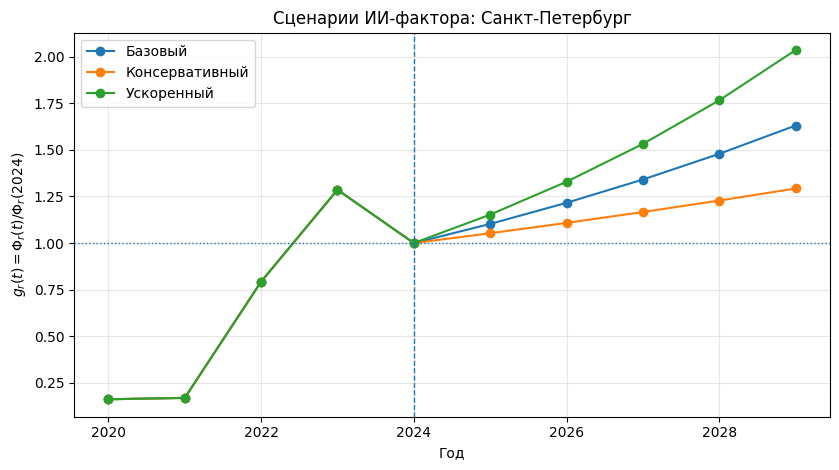

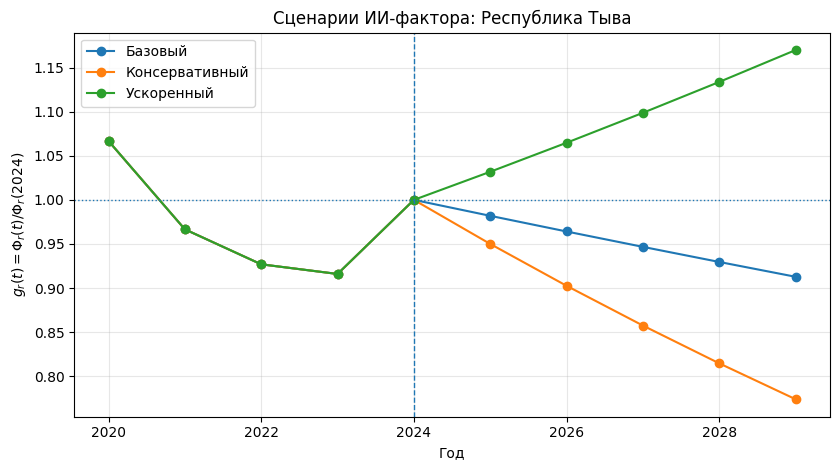

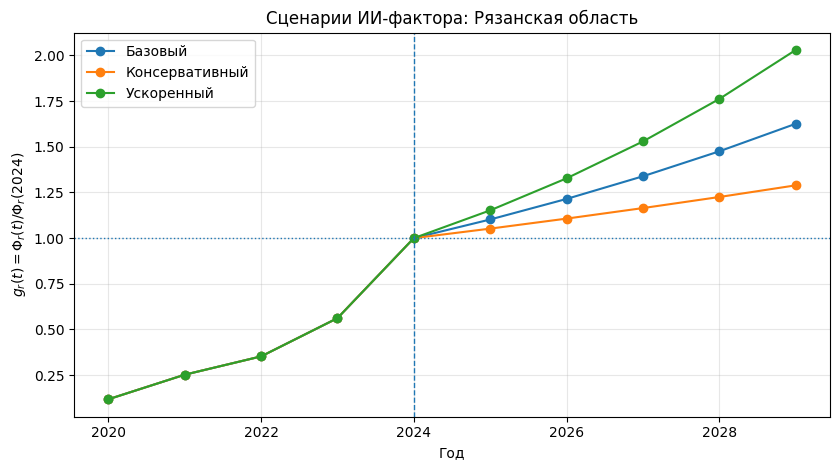

In [16]:
# Все графики Phi: отдельный график для каждого региона
for region in TARGET_REGIONS:
    fig,ax=plt.subplots(figsize=(8.5,4.8))
    for scenario,g in phi[phi.region.eq(region)].groupby('scenario'):
        ax.plot(g.year,g.g_phi,marker='o',label=scenario)
    ax.axvline(BASE_YEAR,linestyle='--',linewidth=1)
    ax.axhline(1,linestyle=':',linewidth=1)
    ax.set_xlabel('Год')
    ax.set_ylabel(r'$g_r(t)=\Phi_r(t)/\Phi_r(2024)$')
    ax.set_title(f'Сценарии ИИ-фактора: {region}')
    ax.grid(alpha=.3); ax.legend()
    fig.tight_layout()
    safe=re.sub(r'[^0-9A-Za-zА-Яа-я]+','_',region)
    fig.savefig(RESULT_DIR/f'07_Phi_{safe}.png',dpi=180,bbox_inches='tight')
    plt.show(); plt.close(fig)

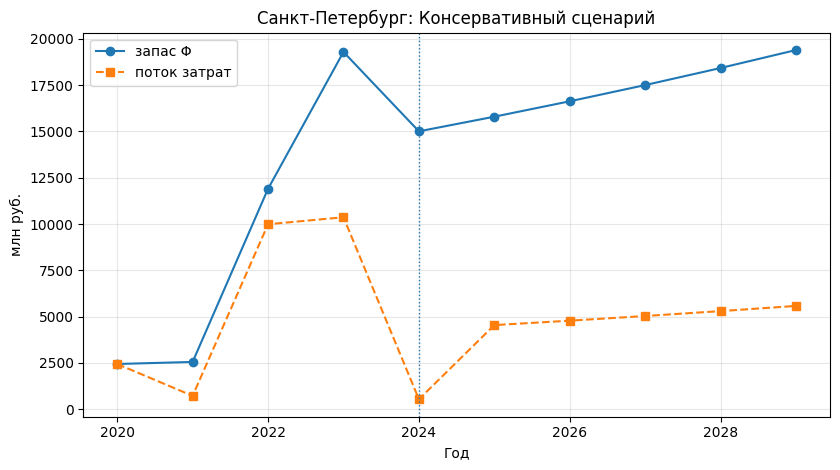

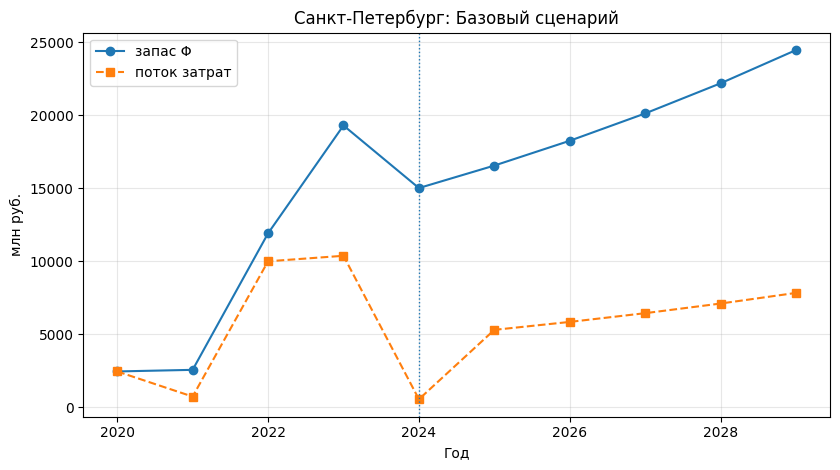

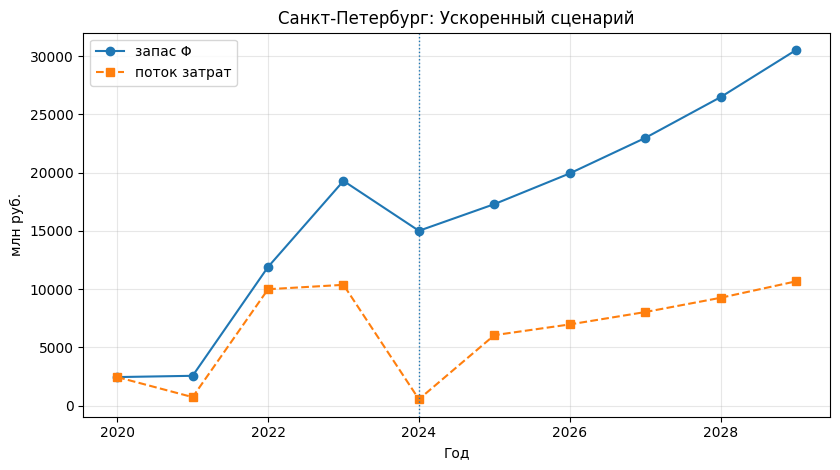

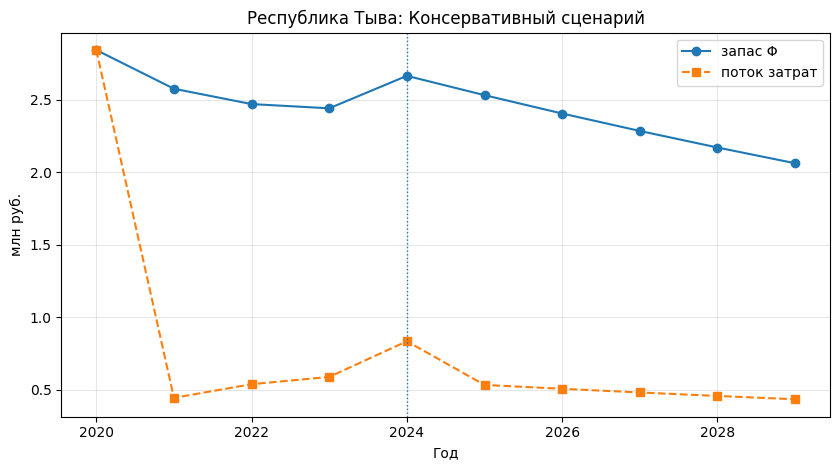

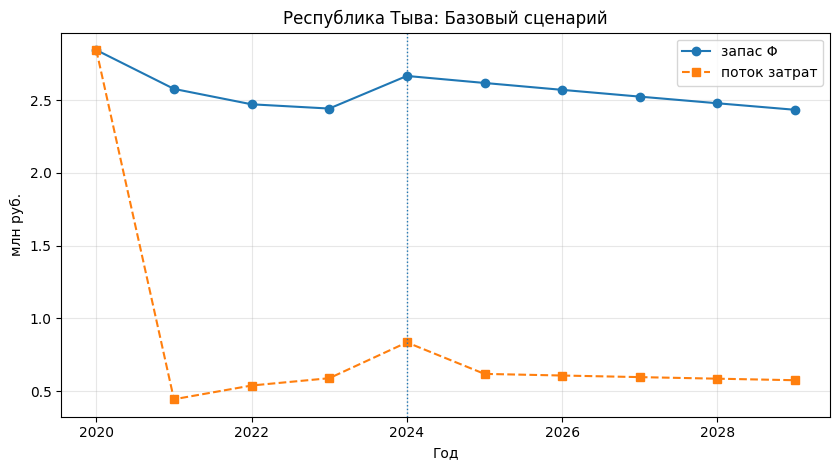

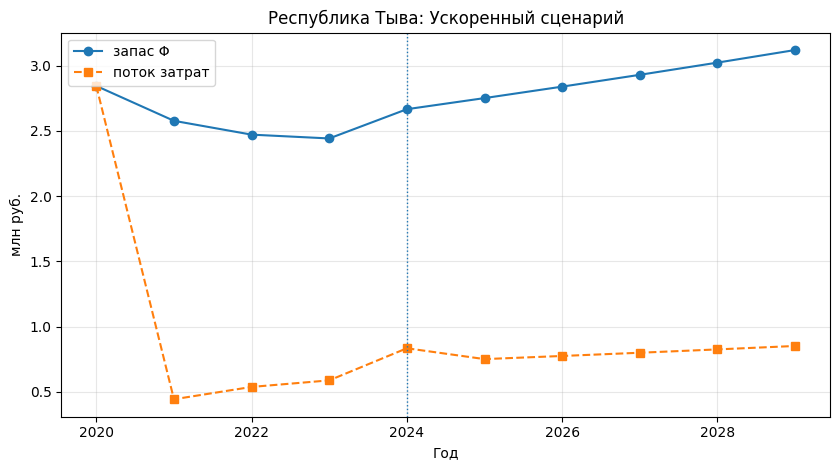

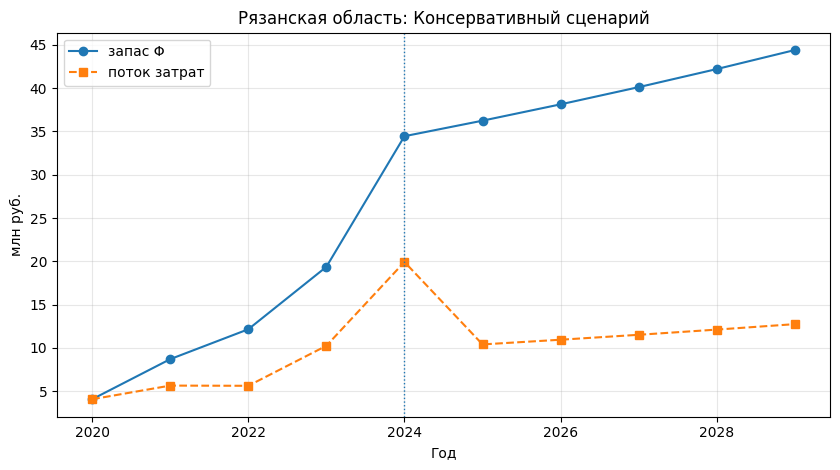

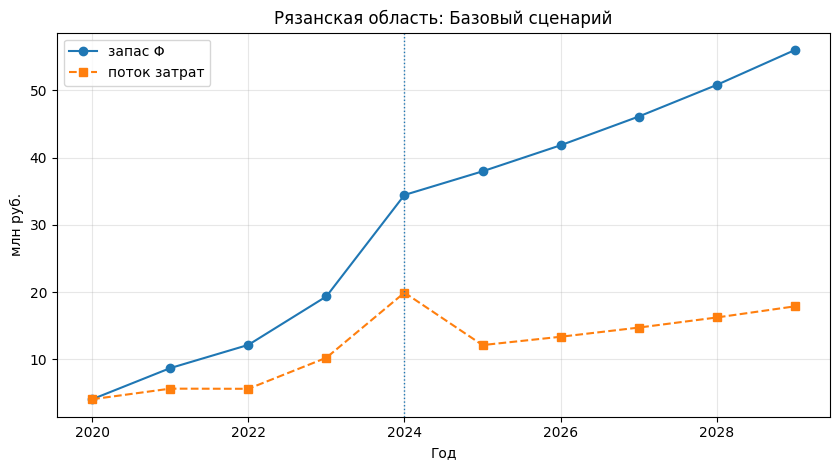

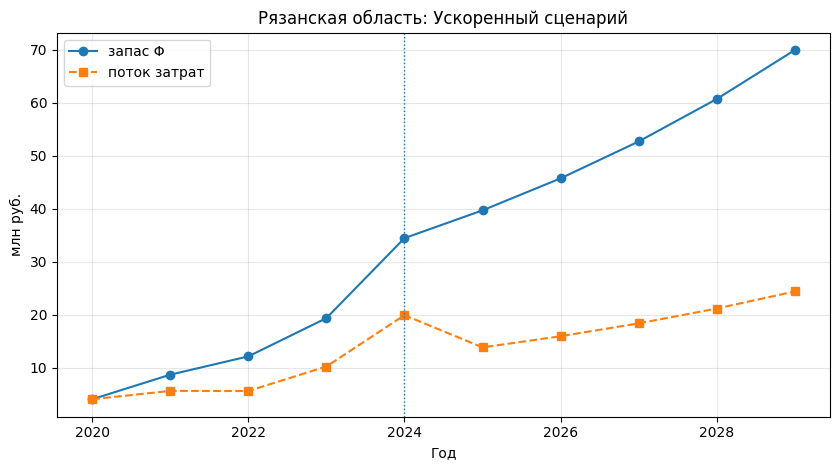

In [17]:
# Абсолютный Phi и требуемый поток затрат для каждого региона
for region in TARGET_REGIONS:
    for scenario in SCENARIO_SHIFT:
        g=phi[(phi.region.eq(region))&(phi.scenario.eq(scenario))]
        fig,ax=plt.subplots(figsize=(8.5,4.8))
        ax.plot(g.year,g.Phi,marker='o',label='запас Φ')
        ax.plot(g.year,g.implied_skvoz_flow,marker='s',linestyle='--',label='поток затрат')
        ax.axvline(BASE_YEAR,linestyle=':',linewidth=1)
        ax.set_xlabel('Год'); ax.set_ylabel('млн руб.')
        ax.set_title(f'{region}: {scenario} сценарий')
        ax.grid(alpha=.3); ax.legend()
        fig.tight_layout()
        safe=re.sub(r'[^0-9A-Za-zА-Яа-я]+','_',region+'_'+scenario)
        fig.savefig(RESULT_DIR/f'08_Phi_и_поток_{safe}.png',dpi=160,bbox_inches='tight')
        plt.show(); plt.close(fig)

## 6. Калибровка нормированной ламповой характеристики по каждой отрасли

Критерии допуска в количественный блок:

- не менее четырёх положительных наблюдений;
- $R^2\geq0.50$;
- ранговая корреляция между затратами и ВДС не ниже $0.50$.

Все калибровочные графики выводятся, но в расчёт эффекта включаются только допущенные отрасли.

In [18]:
def triode_multiplier(z,lam):
    z=np.clip(np.asarray(z,float),0,None)
    num=-np.expm1(-lam*z**1.5)
    den=-np.expm1(-lam)
    if den<1e-12: return z**1.5
    return num/den

def fit_sector_triode(g):
    g=g.sort_values('year').copy()
    g=g[(g.skvozcosts_abs_s>0)&(g.VDS_s>0)]
    if len(g)<4 or BASE_YEAR not in g.year.values: return None
    base=g[g.year.eq(BASE_YEAR)].iloc[-1]
    x0=float(base.skvozcosts_abs_s); y0=float(base.VDS_s)
    z=g.skvozcosts_abs_s.to_numpy(float)/x0
    y=g.VDS_s.to_numpy(float)/y0
    def loss(log_lam):
        lam=float(np.exp(log_lam))
        pred=triode_multiplier(z,lam)
        return float(np.mean((y-pred)**2))
    res=minimize_scalar(loss,bounds=(np.log(1e-4),np.log(100)),method='bounded')
    lam=float(np.exp(res.x)); pred=triode_multiplier(z,lam)
    sse=float(np.sum((y-pred)**2)); sst=float(np.sum((y-y.mean())**2))
    r2=np.nan if sst==0 else 1-sse/sst
    rho=float(spearmanr(z,y).statistic)
    rmse=float(np.sqrt(np.mean((y-pred)**2)))
    accepted=bool(len(g)>=4 and np.isfinite(r2) and r2>=R2_MIN and np.isfinite(rho) and rho>=RHO_MIN)
    return {'n_obs':len(g),'x0':x0,'y0':y0,'lambda':lam,'r2':r2,'spearman_rho':rho,'rmse_norm':rmse,
            'z_min_observed':float(z.min()),'z_max_observed':float(z.max()),'accepted':accepted}

rows=[]
for sector,g in sectors.groupby('sector'):
    fit=fit_sector_triode(g)
    if fit:
        fit['sector']=sector
        rows.append(fit)
sector_models=pd.DataFrame(rows).merge(sector_profiles[['sector','cluster','profile']],on='sector',how='left')
sector_models['status']=np.where(sector_models.accepted,'ДОПУЩЕНА','ИСКЛЮЧЕНА')
accepted_models=sector_models[sector_models.accepted].copy().sort_values('r2',ascending=False)
print(f'Оценено моделей: {len(sector_models)}; допущено: {len(accepted_models)}; исключено: {len(sector_models)-len(accepted_models)}')
display(sector_models.sort_values(['accepted','r2'],ascending=[False,False])[['sector','profile','n_obs','lambda','r2','spearman_rho','status']])

Оценено моделей: 29; допущено: 5; исключено: 24


,sector,profile,n_obs,lambda,r2,spearman_rho,status
7,Научные исследования и разработки,высокая IT-интенсивность; акцент на обучение,4,2.842906,0.964440,1.0,ДОПУЩЕНА
13,"Производство компьютеров, электронных и оптических изделий",высокая IT-интенсивность; акцент на обучение,4,23.663984,0.674663,0.6,ДОПУЩЕНА
28,"Торговля розничная, кроме торговли автотранспортными средствами и мотоциклами",умеренная IT-интенсивность; акцент на сквозные технологии,4,20.801169,0.666451,0.8,ДОПУЩЕНА
20,Производство химических веществ и химических продуктов,умеренная IT-интенсивность; акцент на сквозные технологии,4,2.160151,0.573141,0.8,ДОПУЩЕНА
11,"Производство готовых металлических изделий, кроме машин и оборудования",высокая IT-интенсивность; акцент на обучение,4,8.875629,0.539745,0.8,ДОПУЩЕНА
10,"Производство автотранспортных средств, прицепов и полуприцепов",высокая IT-интенсивность; акцент на обучение,4,5.496050,0.402292,0.2,ИСКЛЮЧЕНА
24,Рыболовство и рыбоводство,умеренная IT-интенсивность; акцент на сквозные технологии,4,1.452110,0.359346,0.8,ИСКЛЮЧЕНА
27,"Торговля оптовая, кроме оптовой торговли автотранспортными средствами и мотоциклами",умеренная IT-интенсивность; акцент на сквозные технологии,4,1.514512,0.315996,0.6,ИСКЛЮЧЕНА
22,"Растениеводство и животноводство, охота и предоставление соответствующих услуг в этих областях",умеренная IT-интенсивность; акцент на сквозные технологии,4,1.699979,0.283055,0.8,ИСКЛЮЧЕНА
26,Торговля оптовая и розничная автотранспортными средствами и мотоциклами и их ремонт,умеренная IT-интенсивность; акцент на сквозные технологии,4,6.649159,-0.002009,0.4,ИСКЛЮЧЕНА


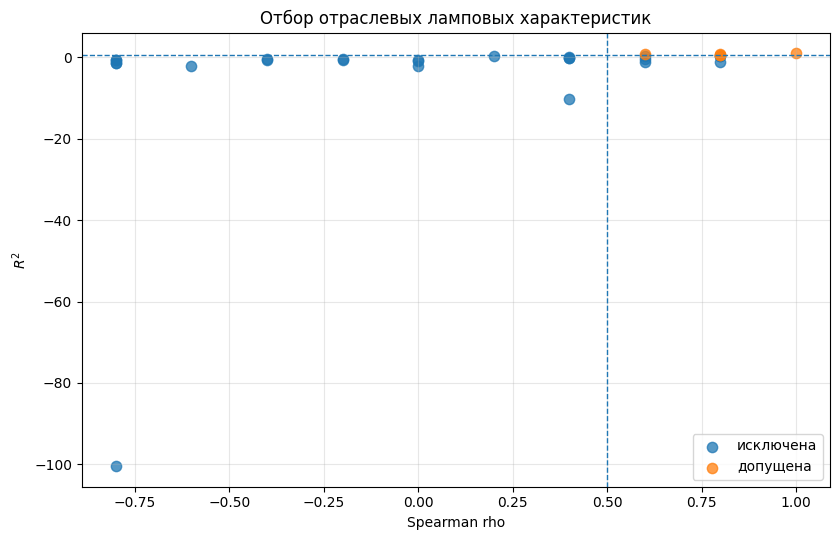

In [19]:
# Диагностика качества всех отраслевых моделей
fig,ax=plt.subplots(figsize=(8.5,5.5))
for accepted,g in sector_models.groupby('accepted'):
    ax.scatter(g.spearman_rho,g.r2,s=55,label='допущена' if accepted else 'исключена',alpha=.75)
ax.axhline(R2_MIN,linestyle='--',linewidth=1)
ax.axvline(RHO_MIN,linestyle='--',linewidth=1)
ax.set_xlabel('Spearman rho')
ax.set_ylabel('$R^2$')
ax.set_title('Отбор отраслевых ламповых характеристик')
ax.grid(alpha=.3); ax.legend()
fig.tight_layout()
fig.savefig(RESULT_DIR/'09_качество_отраслевых_моделей.png',dpi=180,bbox_inches='tight')
plt.show(); plt.close(fig)

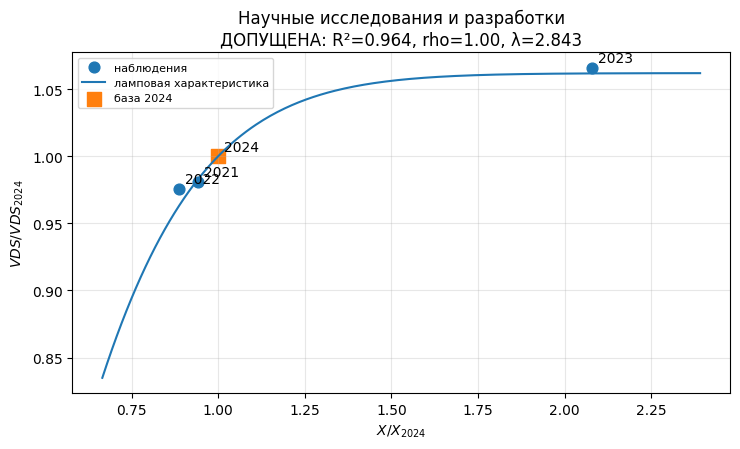

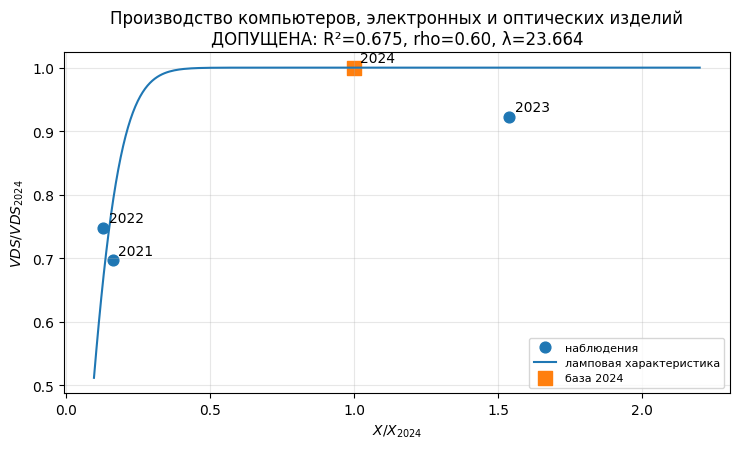

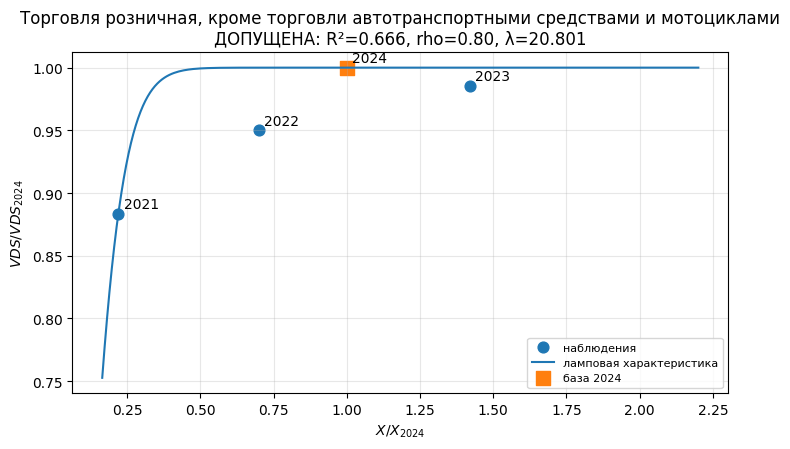

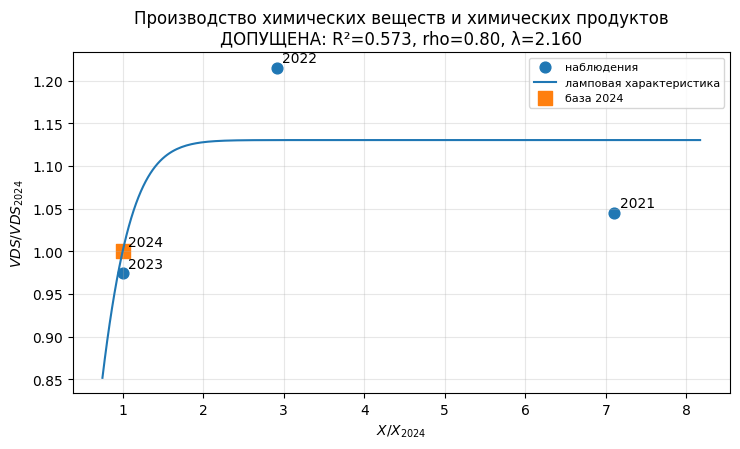

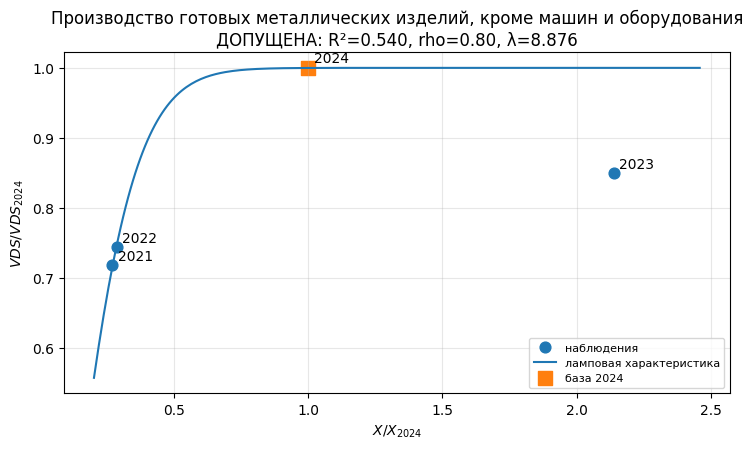

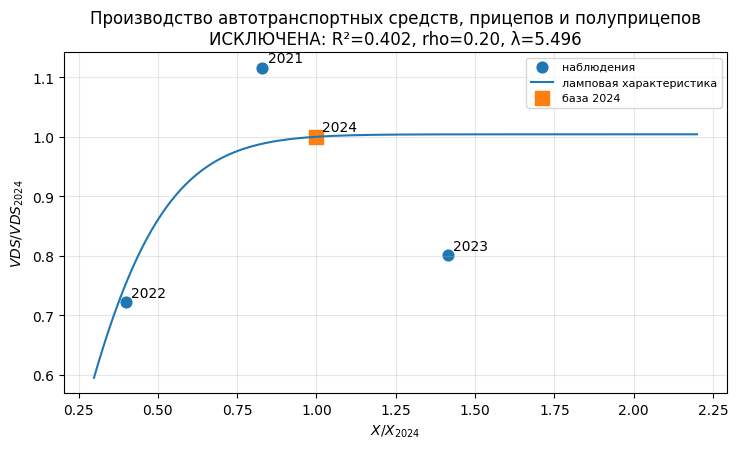

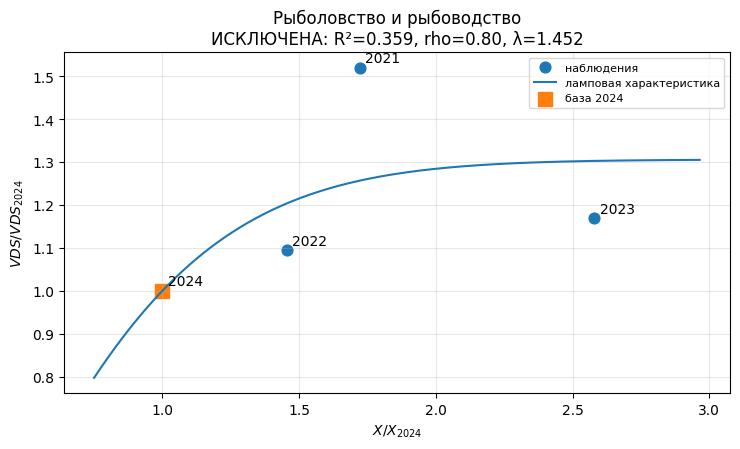

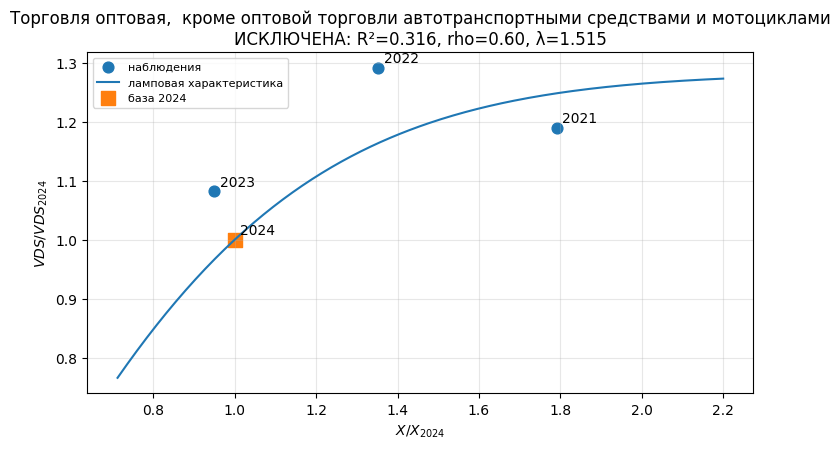

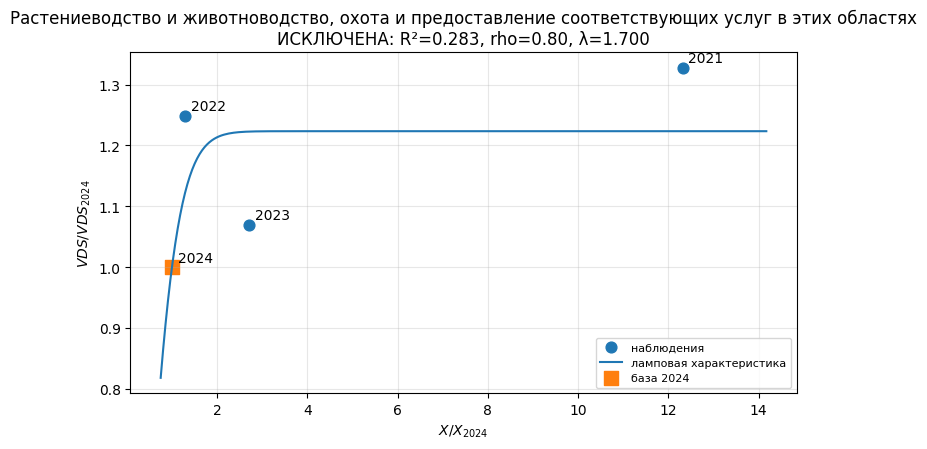

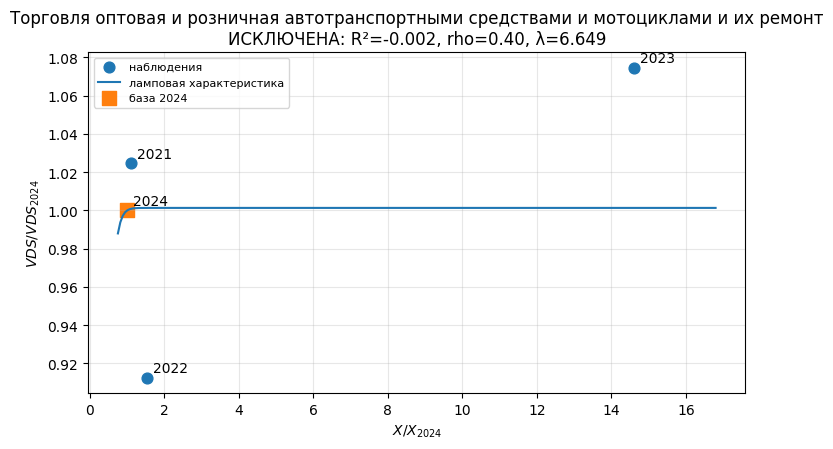

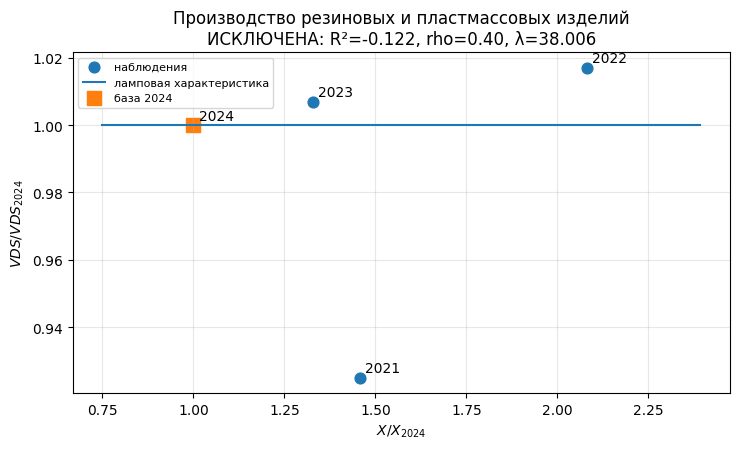

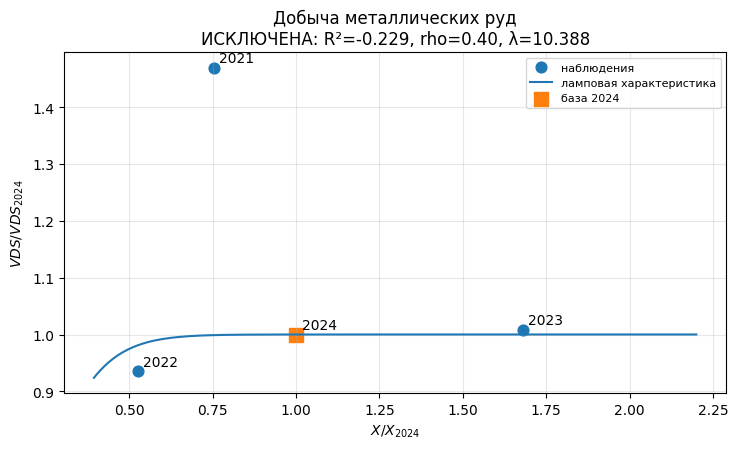

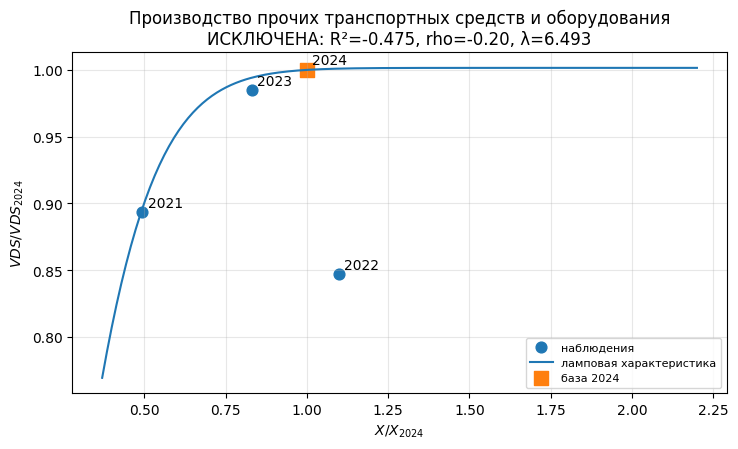

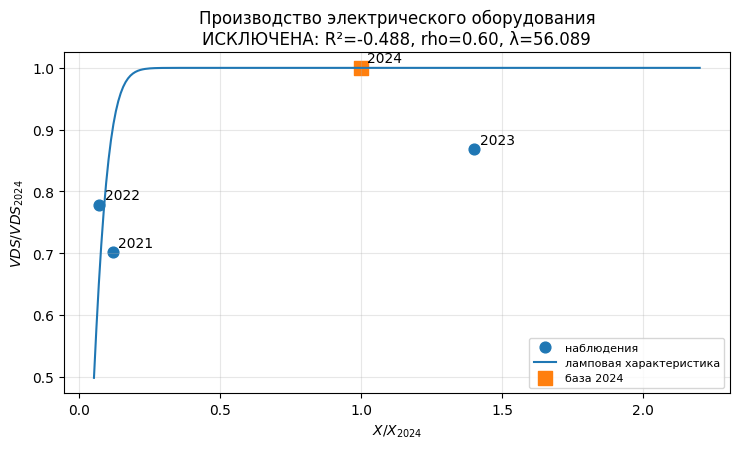

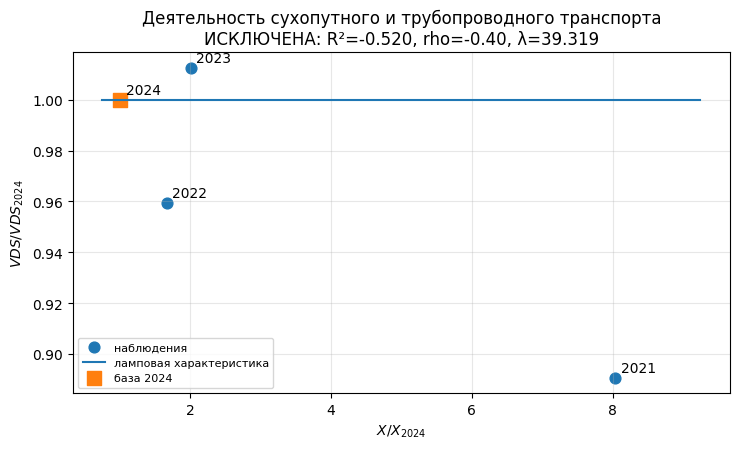

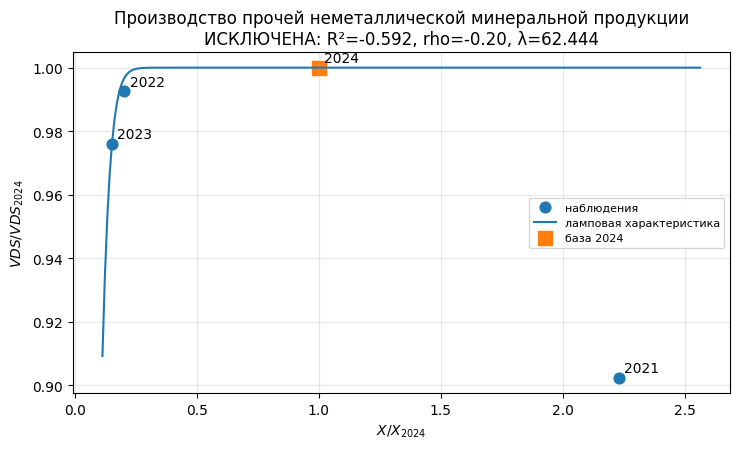

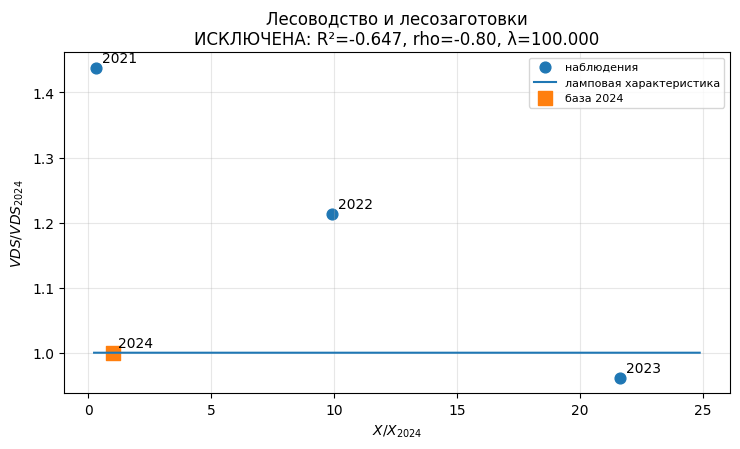

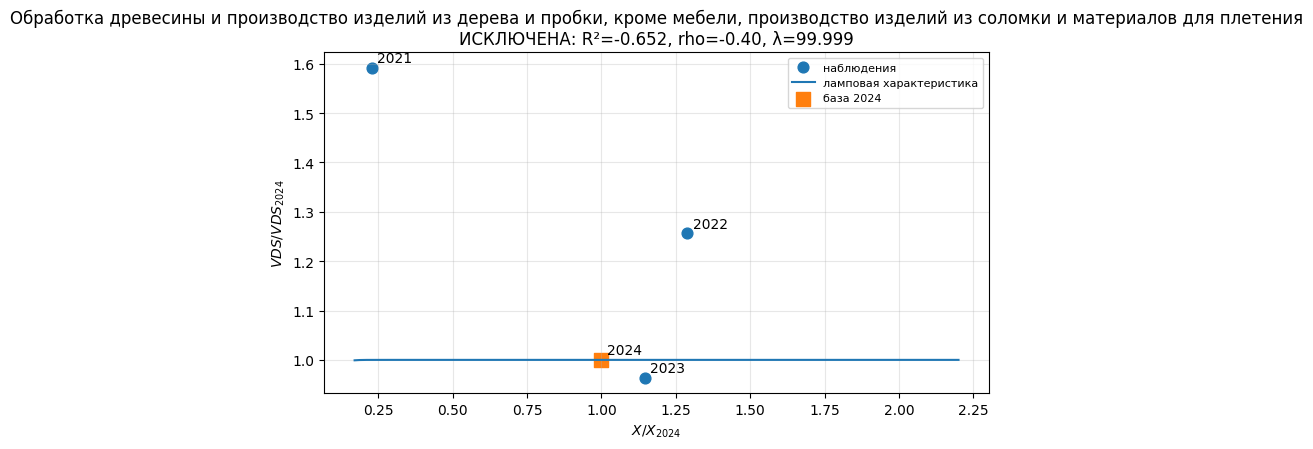

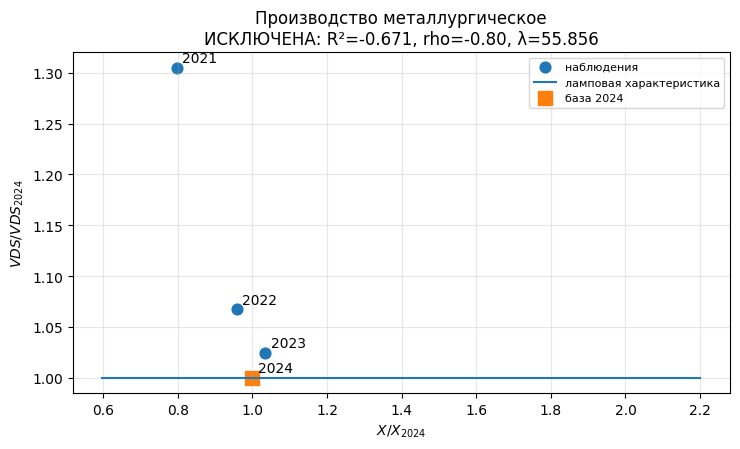

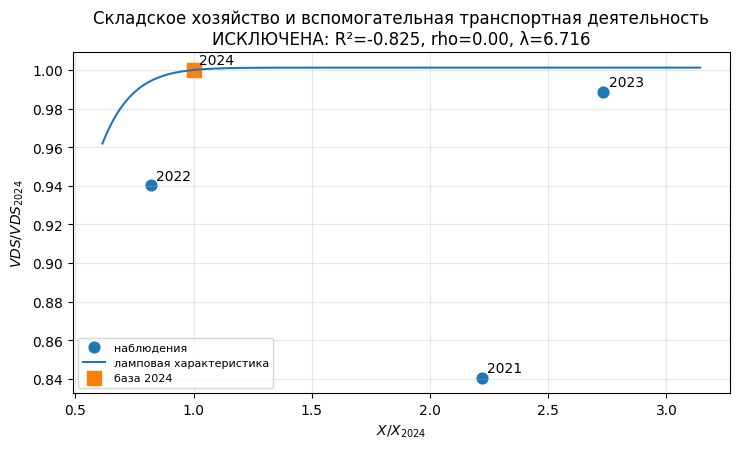

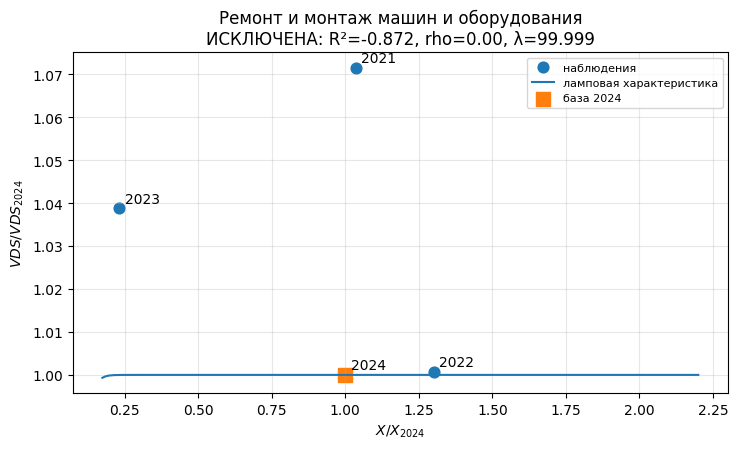

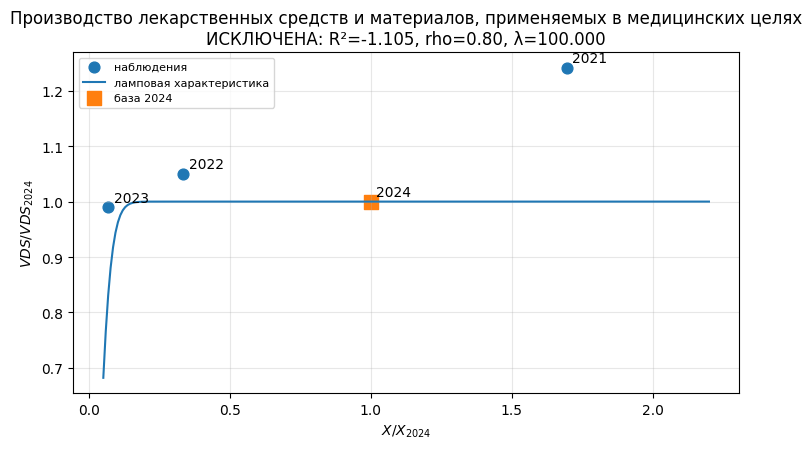

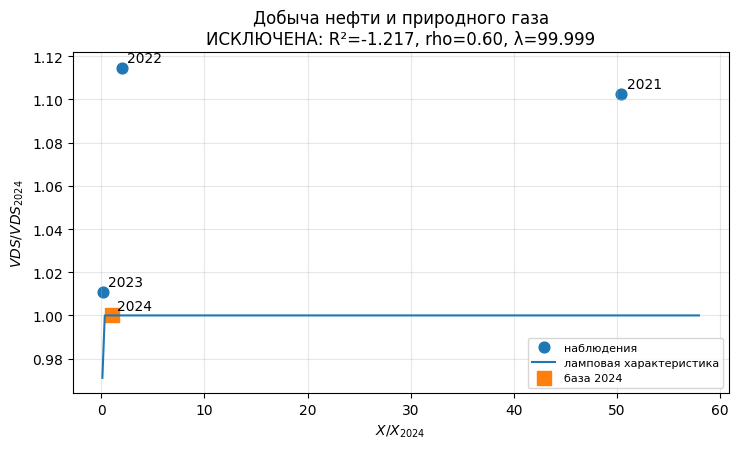

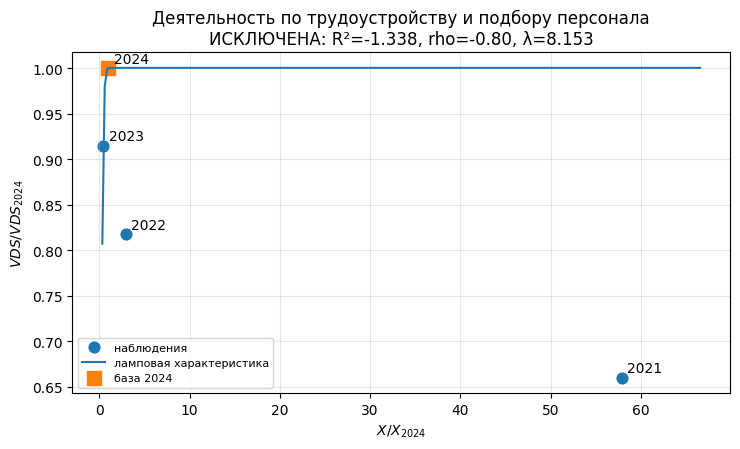

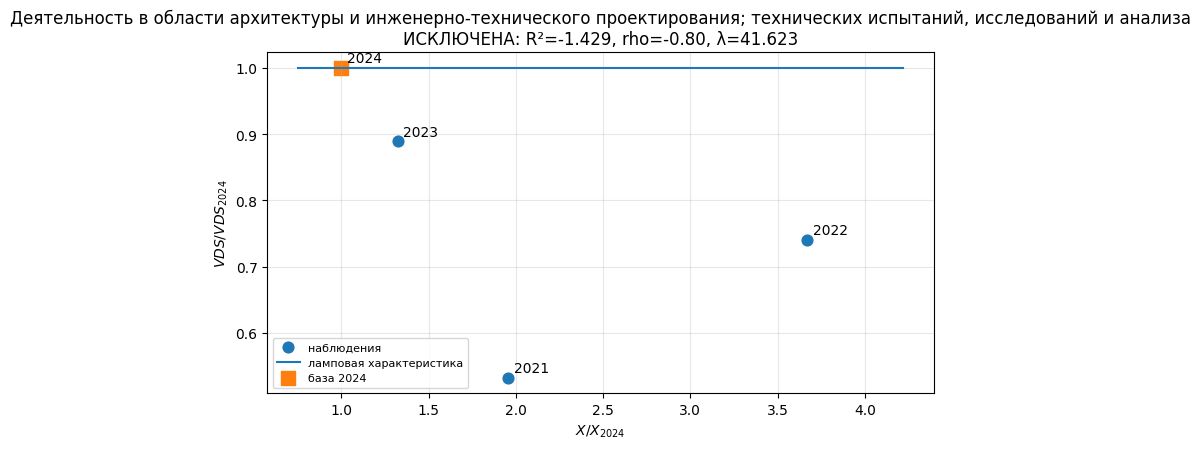

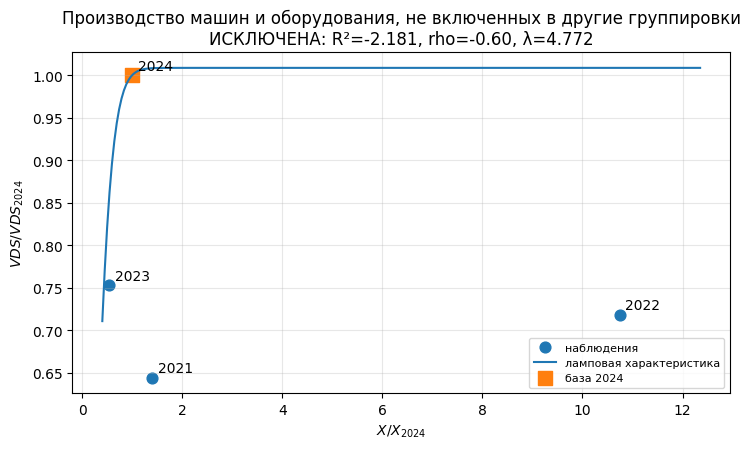

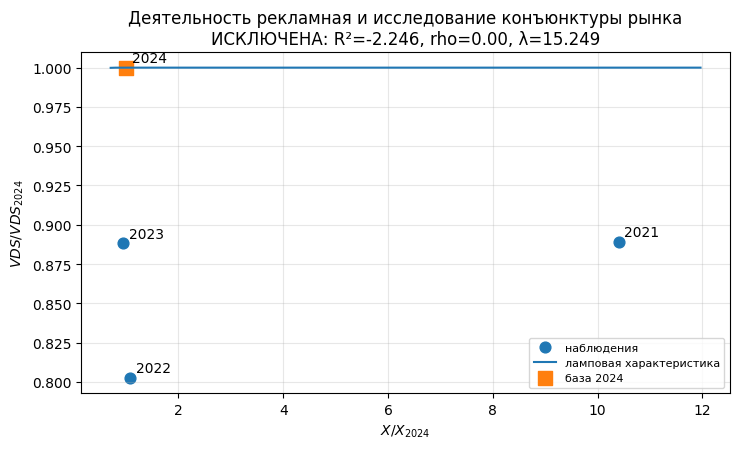

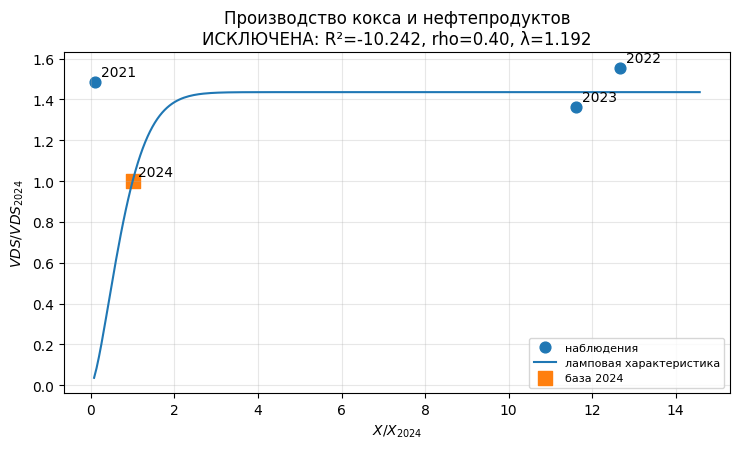

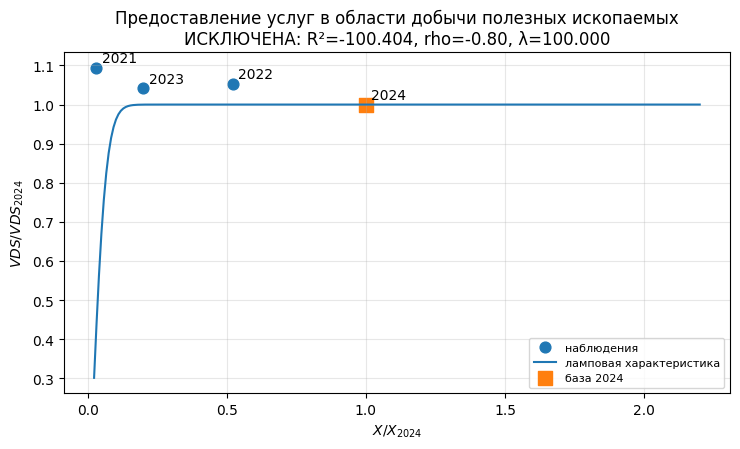

In [20]:
# Все калибровочные графики: одна отрасль — один график
for _,m in sector_models.sort_values(['accepted','r2'],ascending=[False,False]).iterrows():
    g=sectors[sectors.sector.eq(m.sector)].sort_values('year')
    g=g[(g.skvozcosts_abs_s>0)&(g.VDS_s>0)].copy()
    z=g.skvozcosts_abs_s.to_numpy(float)/m.x0
    y=g.VDS_s.to_numpy(float)/m.y0
    z_grid=np.linspace(max(0.02,z.min()*.75),max(2.2,z.max()*1.15),250)
    pred=triode_multiplier(z_grid,m['lambda'])
    fig,ax=plt.subplots(figsize=(7.5,4.6))
    ax.scatter(z,y,s=60,label='наблюдения')
    ax.plot(z_grid,pred,label='ламповая характеристика')
    ax.scatter([1],[1],s=90,marker='s',label='база 2024')
    for _,r in g.iterrows():
        ax.annotate(str(int(r.year)),(r.skvozcosts_abs_s/m.x0,r.VDS_s/m.y0),xytext=(4,4),textcoords='offset points')
    ax.set_xlabel(r'$X/X_{2024}$')
    ax.set_ylabel(r'$VDS/VDS_{2024}$')
    ax.set_title(f"{m.sector}\n{m.status}: R²={m.r2:.3f}, rho={m.spearman_rho:.2f}, λ={m['lambda']:.3f}")
    ax.grid(alpha=.3); ax.legend(fontsize=8)
    fig.tight_layout()
    safe=re.sub(r'[^0-9A-Za-zА-Яа-я]+','_',m.sector)[:90]
    fig.savefig(RESULT_DIR/f'10_калибровка_{safe}.png',dpi=150,bbox_inches='tight')
    plt.show(); plt.close(fig)

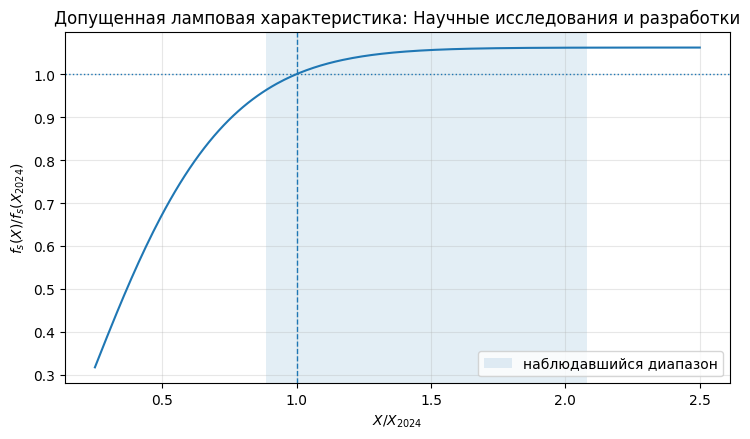

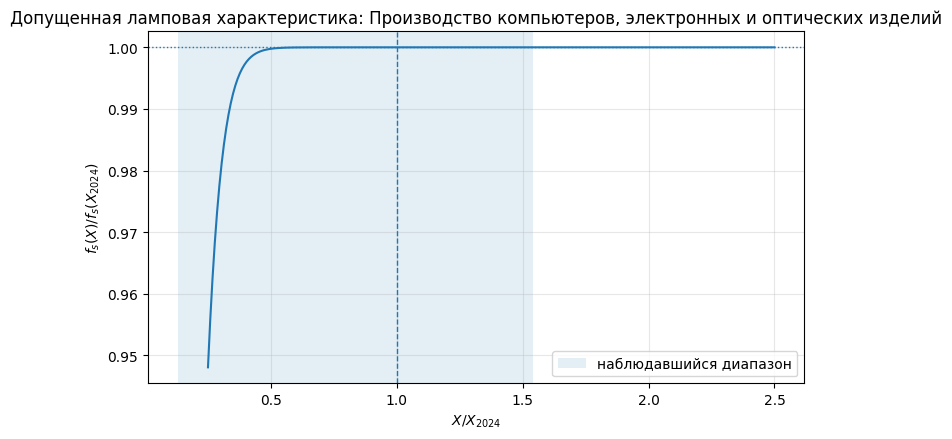

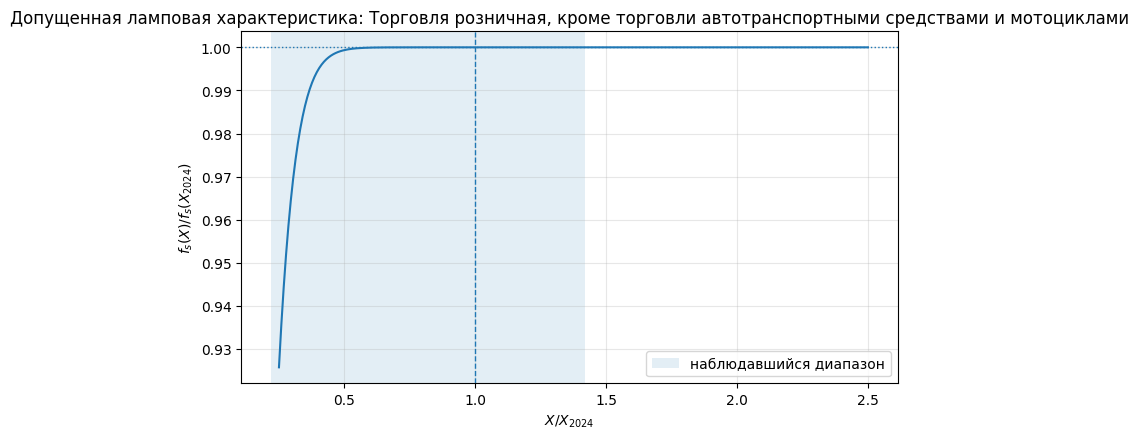

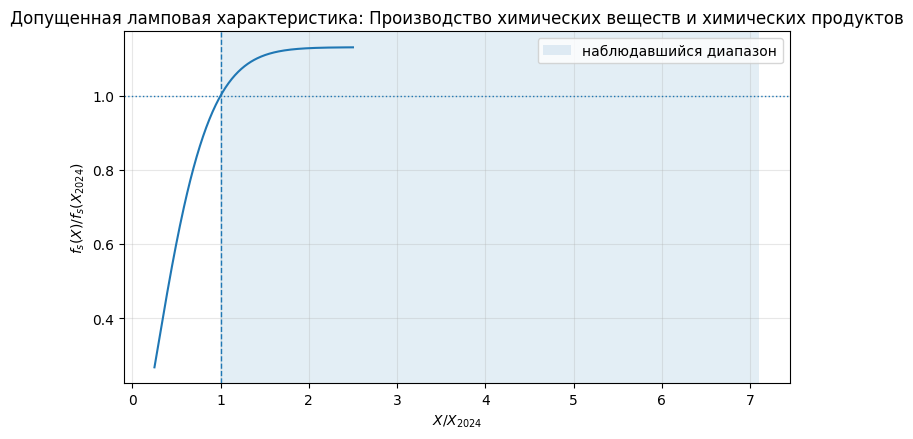

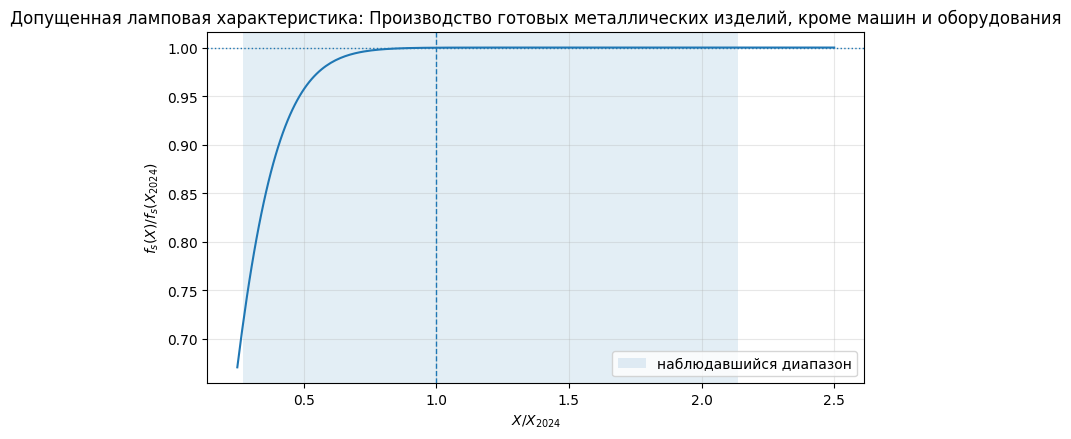

In [21]:
# Статические характеристики всех допущенных отраслей
z_grid=np.linspace(0.25,2.5,250)
for _,m in accepted_models.iterrows():
    fig,ax=plt.subplots(figsize=(7.5,4.5))
    ax.plot(z_grid,triode_multiplier(z_grid,m['lambda']))
    ax.axvline(1,linestyle='--',linewidth=1)
    ax.axhline(1,linestyle=':',linewidth=1)
    ax.axvspan(m.z_min_observed,m.z_max_observed,alpha=.12,label='наблюдавшийся диапазон')
    ax.set_xlabel(r'$X/X_{2024}$')
    ax.set_ylabel(r'$f_s(X)/f_s(X_{2024})$')
    ax.set_title(f"Допущенная ламповая характеристика: {m.sector}")
    ax.grid(alpha=.3); ax.legend()
    fig.tight_layout()
    safe=re.sub(r'[^0-9A-Za-zА-Яа-я]+','_',m.sector)[:90]
    fig.savefig(RESULT_DIR/f'11_характеристика_{safe}.png',dpi=160,bbox_inches='tight')
    plt.show(); plt.close(fig)

## 7. Интеграция «регион × отрасль»

В расчёт включаются только допущенные отраслевые модели. Для каждой точки дополнительно проверяется, остаётся ли сценарный вход внутри диапазона, наблюдавшегося в 2021–2024 годах. Выход за диапазон не скрывается, а маркируется как экстраполяция.

In [22]:
pair_rows=[]
for _,m in accepted_models.iterrows():
    for _,r in phi.iterrows():
        z=float(r.g_phi)
        result_index=float(triode_multiplier(z,m['lambda']))
        in_range=bool(m.z_min_observed<=z<=m.z_max_observed)
        pair_rows.append([r.region,r.scenario,int(r.year),r.phase,m.sector,m.profile,z,
                          m.x0*z,result_index,(result_index-1)*100,m.r2,m.spearman_rho,
                          m.z_min_observed,m.z_max_observed,in_range])
pair_effects=pd.DataFrame(pair_rows,columns=['region','scenario','year','phase','sector','sector_profile','g_phi',
    'implied_sector_skvoz_costs','result_index','effect_pct','model_r2','spearman_rho','z_min_observed','z_max_observed','within_observed_range'])
print('Строк сценарного расчёта:',len(pair_effects))
display(pair_effects.head())

Строк сценарного расчёта: 450


,region,scenario,year,phase,sector,sector_profile,g_phi,implied_sector_skvoz_costs,result_index,effect_pct,model_r2,spearman_rho,z_min_observed,z_max_observed,within_observed_range
0,Санкт-Петербург,Консервативный,2020,факт,Научные исследования и разработки,высокая IT-интенсивность; акцент на обучение,0.162738,132.603466,0.180786,-81.921411,0.96444,1.0,0.887173,2.079043,False
1,Санкт-Петербург,Консервативный,2021,факт,Научные исследования и разработки,высокая IT-интенсивность; акцент на обучение,0.170060,138.569564,0.191936,-80.806364,0.96444,1.0,0.887173,2.079043,False
2,Санкт-Петербург,Консервативный,2022,факт,Научные исследования и разработки,высокая IT-интенсивность; акцент на обучение,0.793148,646.280795,0.919318,-8.068210,0.96444,1.0,0.887173,2.079043,False
3,Санкт-Петербург,Консервативный,2023,факт,Научные исследования и разработки,высокая IT-интенсивность; акцент на обучение,1.285627,1047.567032,1.045022,4.502197,0.96444,1.0,0.887173,2.079043,True
4,Санкт-Петербург,Консервативный,2024,факт,Научные исследования и разработки,высокая IT-интенсивность; акцент на обучение,1.000000,814.829583,1.000000,0.000000,0.96444,1.0,0.887173,2.079043,True


> **О близких к нулю эффектах.** У отраслей с большим параметром λ нормированная характеристика выходит на насыщение почти сразу, поэтому при $g_r(t)\approx1$ множитель $m_s\approx1$ и эффект составляет доли процента (значения порядка $10^{-7}\%$ в таблицах — это не ошибка, а признак того, что отрасль уже находится в зоне насыщения и дополнительные вложения почти не дают прироста). Содержательный эффект сосредоточен в отраслях с малой λ (например, НИОКР и химическое производство), которые ещё на растущем участке характеристики.

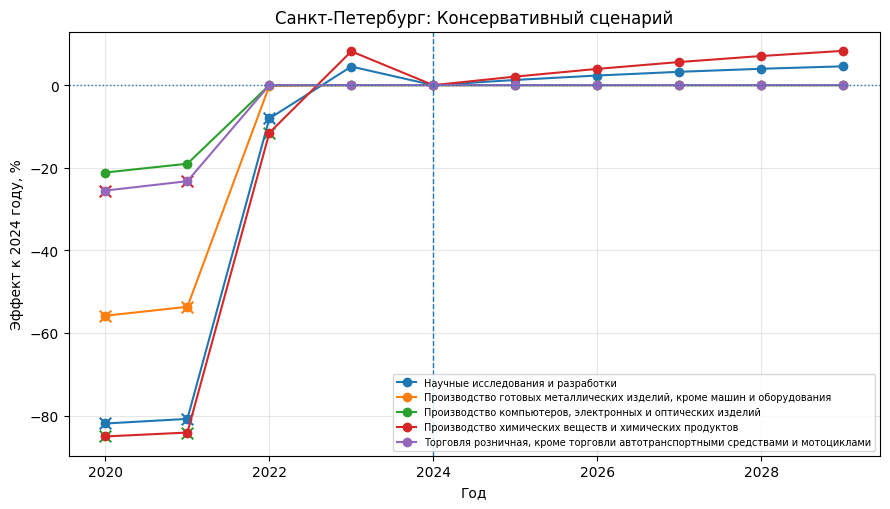

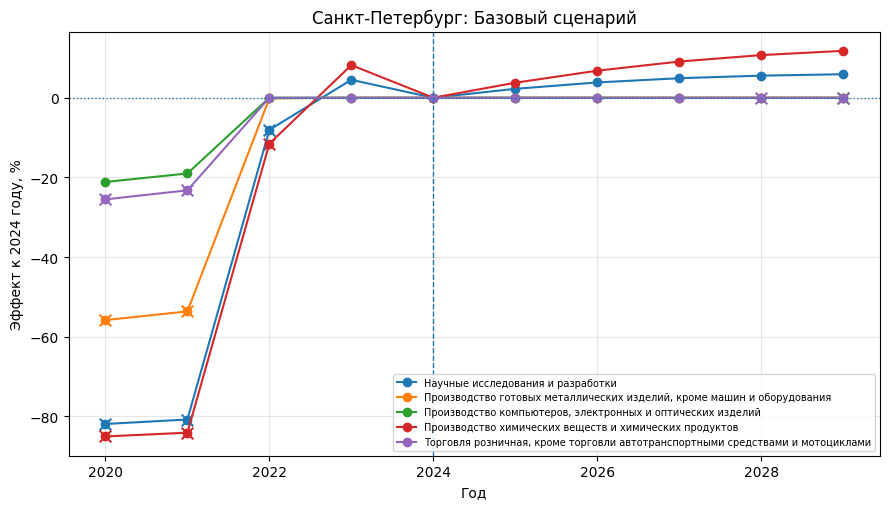

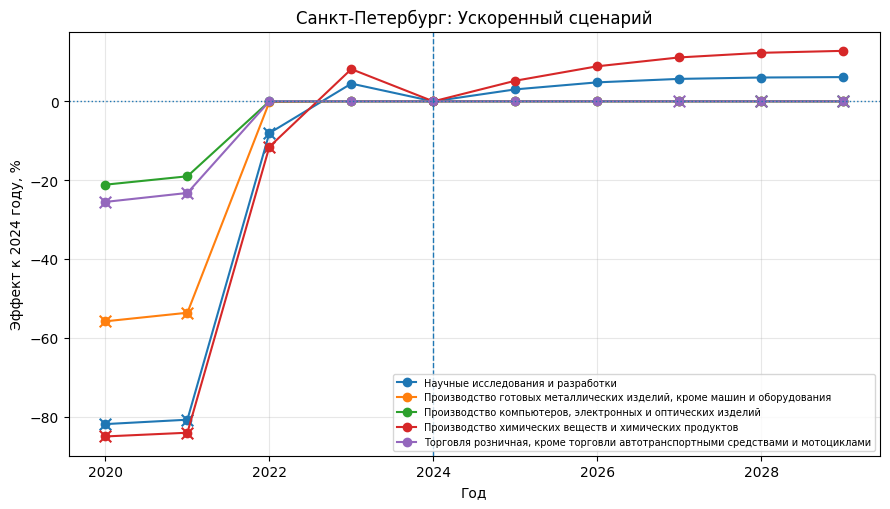

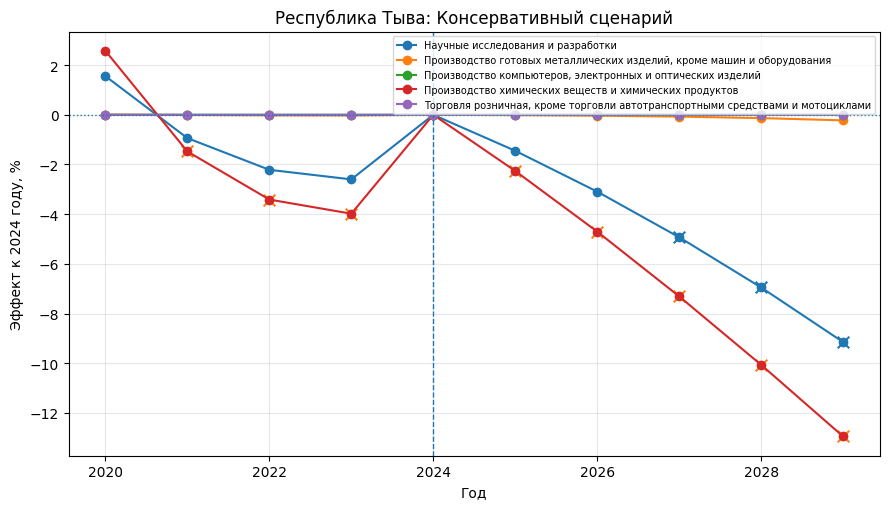

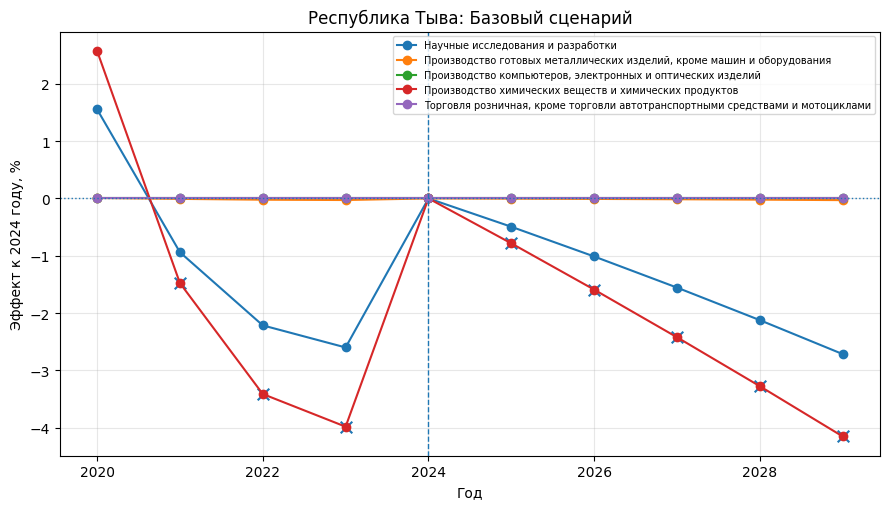

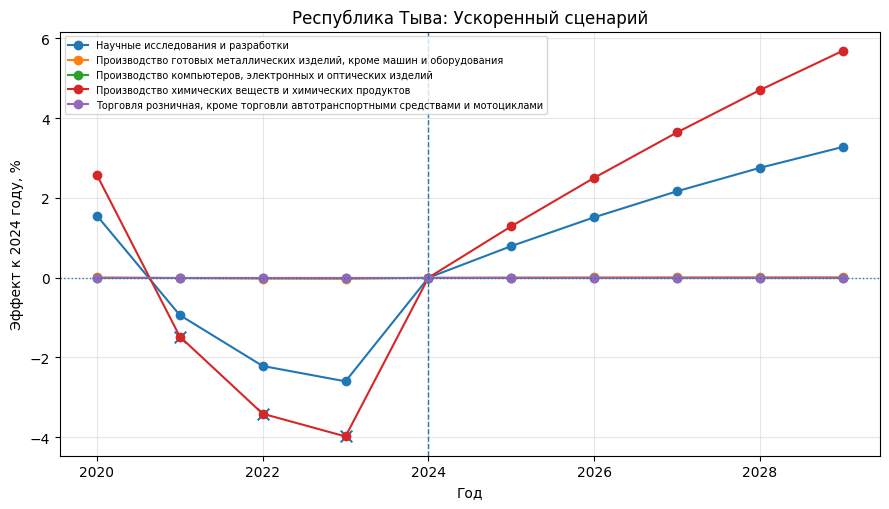

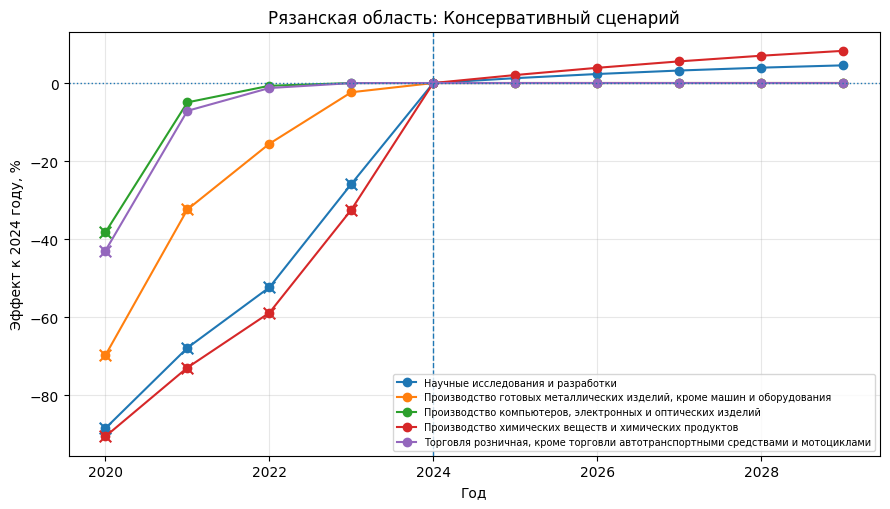

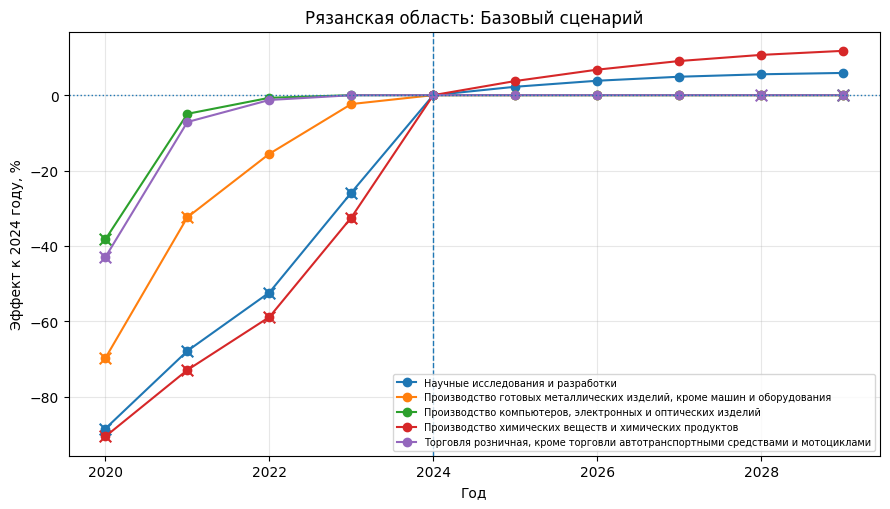

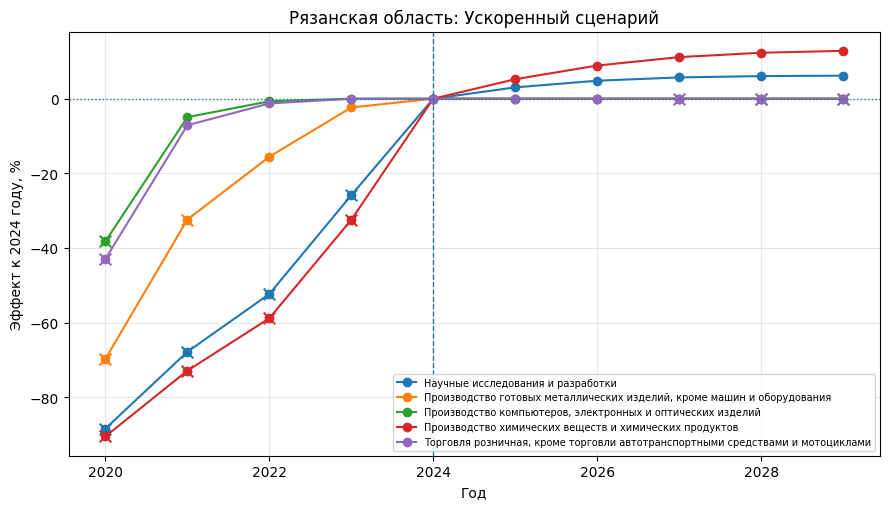

In [23]:
# Все временные графики эффекта: регион × сценарий
for region in TARGET_REGIONS:
    for scenario in SCENARIO_SHIFT:
        sample=pair_effects[(pair_effects.region.eq(region))&(pair_effects.scenario.eq(scenario))]
        fig,ax=plt.subplots(figsize=(9,5.2))
        for sector,g in sample.groupby('sector'):
            ax.plot(g.year,g.effect_pct,marker='o',label=sector)
            ext=g[~g.within_observed_range]
            if len(ext): ax.scatter(ext.year,ext.effect_pct,marker='x',s=70)
        ax.axvline(BASE_YEAR,linestyle='--',linewidth=1)
        ax.axhline(0,linestyle=':',linewidth=1)
        ax.set_xlabel('Год'); ax.set_ylabel('Эффект к 2024 году, %')
        ax.set_title(f'{region}: {scenario} сценарий')
        ax.grid(alpha=.3); ax.legend(fontsize=7,loc='best')
        fig.tight_layout()
        safe=re.sub(r'[^0-9A-Za-zА-Яа-я]+','_',region+'_'+scenario)
        fig.savefig(RESULT_DIR/f'12_эффект_{safe}.png',dpi=170,bbox_inches='tight')
        plt.show(); plt.close(fig)

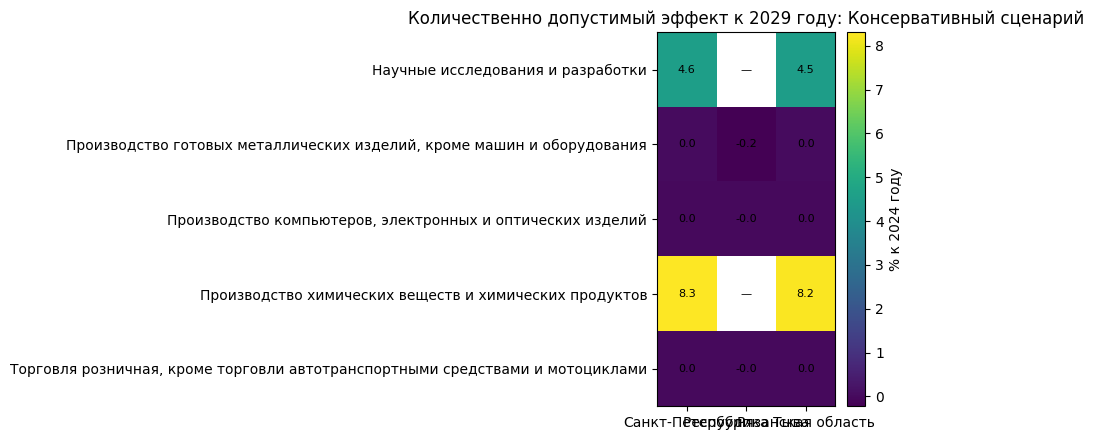

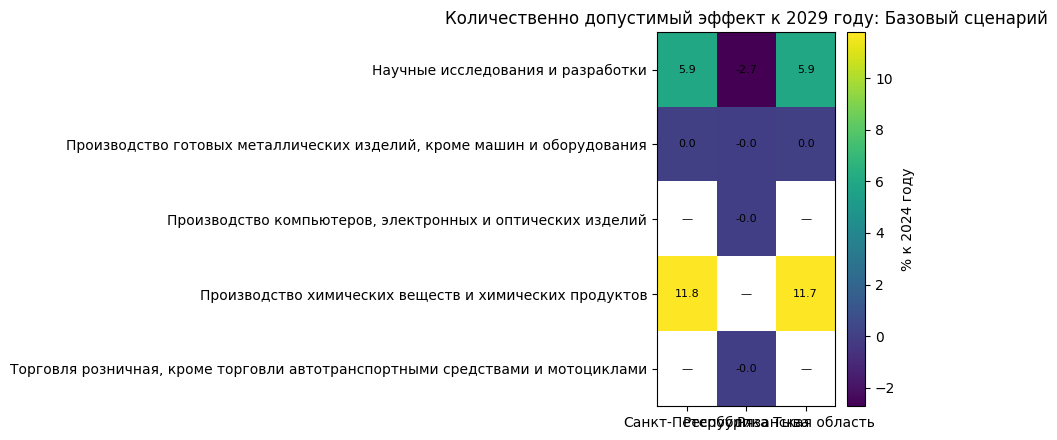

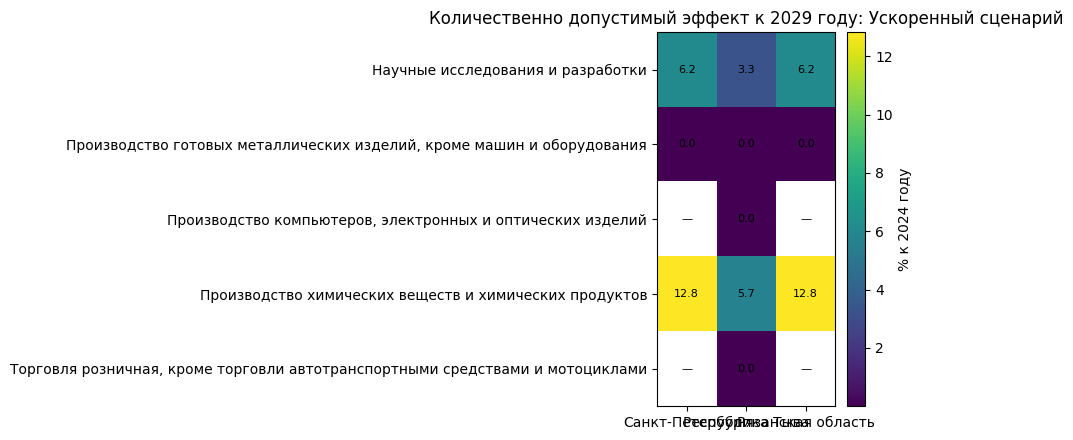

In [24]:
# Тепловые карты 2029 года для каждого сценария. Вне наблюдаемого диапазона — пустая ячейка.
for scenario in SCENARIO_SHIFT:
    h=pair_effects[(pair_effects.year.eq(FORECAST_END))&(pair_effects.scenario.eq(scenario))].copy()
    h.loc[~h.within_observed_range,'effect_pct']=np.nan
    heat=h.pivot(index='sector',columns='region',values='effect_pct').reindex(columns=TARGET_REGIONS)
    fig,ax=plt.subplots(figsize=(9,max(4.5,len(heat)*.65)))
    im=ax.imshow(heat.values,aspect='auto')
    ax.set_xticks(range(len(heat.columns)),heat.columns)
    ax.set_yticks(range(len(heat.index)),heat.index)
    for i in range(len(heat.index)):
        for j in range(len(heat.columns)):
            val=heat.iloc[i,j]
            ax.text(j,i,'—' if pd.isna(val) else f'{val:.1f}',ha='center',va='center',fontsize=8)
    ax.set_title(f'Количественно допустимый эффект к {FORECAST_END} году: {scenario} сценарий')
    fig.colorbar(im,ax=ax,label='% к 2024 году')
    fig.tight_layout()
    safe=re.sub(r'[^0-9A-Za-zА-Яа-я]+','_',scenario)
    fig.savefig(RESULT_DIR/f'13_тепловая_карта_{safe}.png',dpi=180,bbox_inches='tight')
    plt.show(); plt.close(fig)

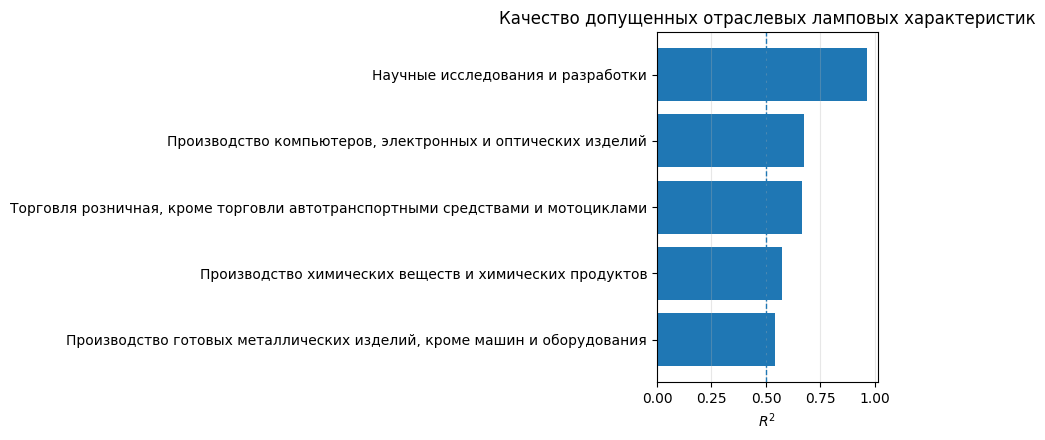

In [25]:
# Рейтинг допущенных отраслевых моделей по качеству
rank=accepted_models.sort_values('r2')
fig,ax=plt.subplots(figsize=(9,max(4.5,len(rank)*.6)))
ax.barh(rank.sector,rank.r2)
ax.axvline(R2_MIN,linestyle='--',linewidth=1)
ax.set_xlabel('$R^2$')
ax.set_title('Качество допущенных отраслевых ламповых характеристик')
ax.grid(axis='x',alpha=.3)
fig.tight_layout()
fig.savefig(RESULT_DIR/'14_R2_допущенных_моделей.png',dpi=180,bbox_inches='tight')
plt.show(); plt.close(fig)

## 8. Итоговые таблицы и честный количественный вывод

In [26]:
summary_2029=pair_effects[pair_effects.year.eq(FORECAST_END)].copy()
summary_2029['quantitative_ok']=summary_2029.within_observed_range
quantitative_2029=summary_2029[summary_2029.quantitative_ok].sort_values(['region','scenario','effect_pct'],ascending=[True,True,False])
extrapolated_2029=summary_2029[~summary_2029.quantitative_ok].sort_values(['region','scenario','effect_pct'],ascending=[True,True,False])
print('Количественно допустимые результаты 2029 года:')
display(quantitative_2029[['region','scenario','sector','g_phi','effect_pct','model_r2','spearman_rho']])
print('Экстраполяционные результаты — не включать в точные выводы:')
display(extrapolated_2029[['region','scenario','sector','g_phi','effect_pct','z_min_observed','z_max_observed']])

Количественно допустимые результаты 2029 года:


,region,scenario,sector,g_phi,effect_pct,model_r2,spearman_rho
139,Республика Тыва,Базовый,"Производство компьютеров, электронных и оптических изделий",0.912731,-1.039590e-07,0.674663,0.6
229,Республика Тыва,Базовый,"Торговля розничная, кроме торговли автотранспортными средствами и мотоциклами",0.912731,-1.233497e-06,0.666451,0.8
409,Республика Тыва,Базовый,"Производство готовых металлических изделий, кроме машин и оборудования",0.912731,-2.955756e-02,0.539745,0.8
49,Республика Тыва,Базовый,Научные исследования и разработки,0.912731,-2.715275e+00,0.964440,1.0
129,Республика Тыва,Консервативный,"Производство компьютеров, электронных и оптических изделий",0.773781,-1.010620e-05,0.674663,0.6
219,Республика Тыва,Консервативный,"Торговля розничная, кроме торговли автотранспортными средствами и мотоциклами",0.773781,-7.087778e-05,0.666451,0.8
399,Республика Тыва,Консервативный,"Производство готовых металлических изделий, кроме машин и оборудования",0.773781,-2.239164e-01,0.539745,0.8
329,Республика Тыва,Ускоренный,Производство химических веществ и химических продуктов,1.170022,5.690030e+00,0.573141,0.8
59,Республика Тыва,Ускоренный,Научные исследования и разработки,1.170022,3.278598e+00,0.964440,1.0
419,Республика Тыва,Ускоренный,"Производство готовых металлических изделий, кроме машин и оборудования",1.170022,1.265392e-02,0.539745,0.8


Экстраполяционные результаты — не включать в точные выводы:


,region,scenario,sector,g_phi,effect_pct,z_min_observed,z_max_observed
319,Республика Тыва,Базовый,Производство химических веществ и химических продуктов,0.912731,-4.151488e+00,0.998558,7.106009
39,Республика Тыва,Консервативный,Научные исследования и разработки,0.773781,-9.149264e+00,0.887173,2.079043
309,Республика Тыва,Консервативный,Производство химических веществ и химических продуктов,0.773781,-1.294741e+01,0.998558,7.106009
259,Рязанская область,Базовый,"Торговля розничная, кроме торговли автотранспортными средствами и мотоциклами",1.625630,9.250545e-08,0.220275,1.419087
169,Рязанская область,Базовый,"Производство компьютеров, электронных и оптических изделий",1.625630,5.282774e-09,0.129641,1.539612
269,Рязанская область,Ускоренный,"Торговля розничная, кроме торговли автотранспортными средствами и мотоциклами",2.029417,9.250545e-08,0.220275,1.419087
179,Рязанская область,Ускоренный,"Производство компьютеров, электронных и оптических изделий",2.029417,5.282774e-09,0.129641,1.539612
199,Санкт-Петербург,Базовый,"Торговля розничная, кроме торговли автотранспортными средствами и мотоциклами",1.630079,9.250545e-08,0.220275,1.419087
109,Санкт-Петербург,Базовый,"Производство компьютеров, электронных и оптических изделий",1.630079,5.282774e-09,0.129641,1.539612
209,Санкт-Петербург,Ускоренный,"Торговля розничная, кроме торговли автотранспортными средствами и мотоциклами",2.034729,9.250545e-08,0.220275,1.419087


In [27]:
# Экспорт таблиц в CSV
region_profiles.to_csv(RESULT_DIR/'Профили_регионов.csv',index=False,encoding='utf-8-sig')
sector_profiles.to_csv(RESULT_DIR/'Профили_отраслей.csv',index=False,encoding='utf-8-sig')
phi.to_csv(RESULT_DIR/'Сценарии_Phi.csv',index=False,encoding='utf-8-sig')
sector_models.to_csv(RESULT_DIR/'Все_отраслевые_модели.csv',index=False,encoding='utf-8-sig')
accepted_models.to_csv(RESULT_DIR/'Допущенные_отраслевые_модели.csv',index=False,encoding='utf-8-sig')
pair_effects.to_csv(RESULT_DIR/'Все_сценарные_эффекты.csv',index=False,encoding='utf-8-sig')
quantitative_2029.to_csv(RESULT_DIR/'Количественный_итог_2029.csv',index=False,encoding='utf-8-sig')
print('Таблицы сохранены в',RESULT_DIR.resolve())

Таблицы сохранены в /content/results_corrected


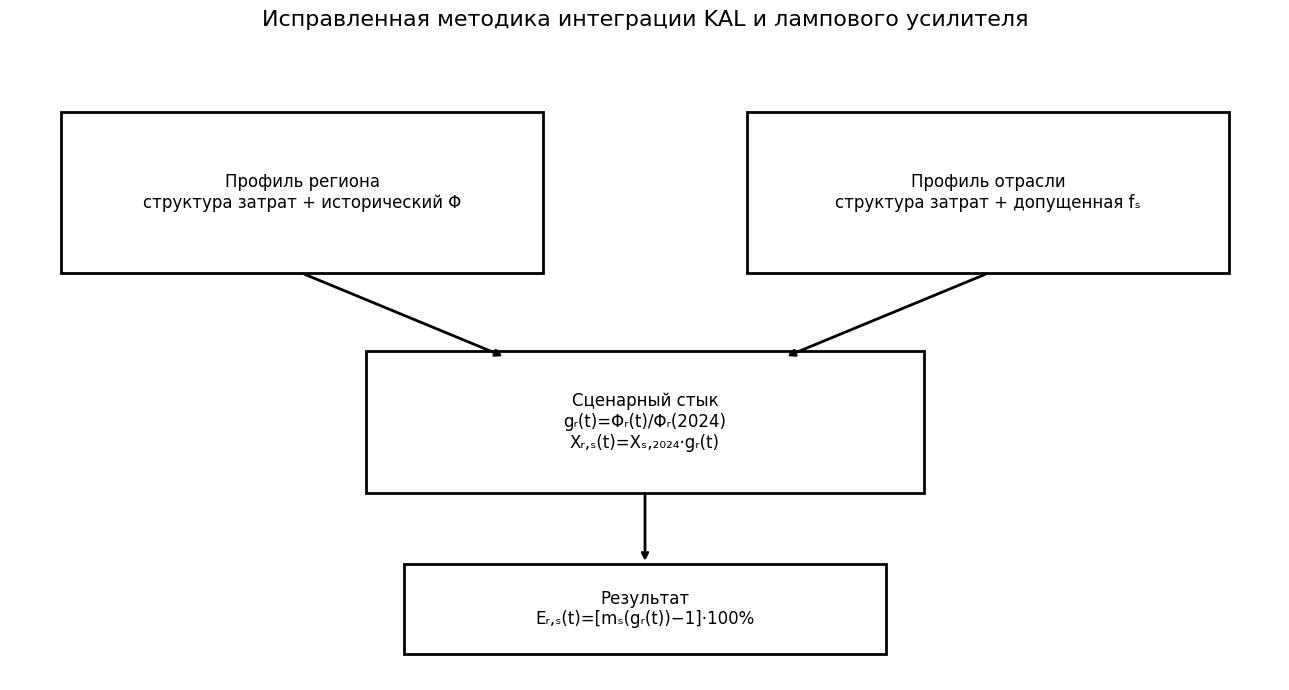

In [28]:
# Схема методики
fig,ax=plt.subplots(figsize=(13,7))
ax.axis('off')
boxes=[
    (.04,.63,.38,.25,'Профиль региона\nструктура затрат + исторический Φ'),
    (.58,.63,.38,.25,'Профиль отрасли\nструктура затрат + допущенная fₛ'),
    (.28,.29,.44,.22,'Сценарный стык\ngᵣ(t)=Φᵣ(t)/Φᵣ(2024)\nXᵣ,ₛ(t)=Xₛ,₂₀₂₄·gᵣ(t)'),
    (.31,.04,.38,.14,'Результат\nEᵣ,ₛ(t)=[mₛ(gᵣ(t))−1]·100%')]
for x,y,w,h,text in boxes:
    ax.add_patch(plt.Rectangle((x,y),w,h,fill=False,linewidth=2,transform=ax.transAxes))
    ax.text(x+w/2,y+h/2,text,ha='center',va='center',fontsize=12,transform=ax.transAxes)
ax.annotate('',xy=(.39,.50),xytext=(.23,.63),arrowprops=dict(arrowstyle='->',lw=2),xycoords=ax.transAxes)
ax.annotate('',xy=(.61,.50),xytext=(.77,.63),arrowprops=dict(arrowstyle='->',lw=2),xycoords=ax.transAxes)
ax.annotate('',xy=(.50,.18),xytext=(.50,.29),arrowprops=dict(arrowstyle='->',lw=2),xycoords=ax.transAxes)
ax.set_title('Исправленная методика интеграции KAL и лампового усилителя',fontsize=16)
fig.tight_layout()
fig.savefig(RESULT_DIR/'00_схема_методики.png',dpi=200,bbox_inches='tight')
plt.show(); plt.close(fig)